In [1]:
# --- High-resolution plot settings ---
# Bumps inline (notebook display) DPI and saved-figure DPI.
# To revert: delete this cell (or restore from starship_science_graphs.ipynb.bak).
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150       # on-screen / inline rendering
plt.rcParams['savefig.dpi'] = 300      # PNG/JPG export resolution


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import math as math
# --- Theme Configuration ---
# Feel free to experiment with these colors!
BACKGROUND_COLOR = '#2c3e50'  # Dark slate blue
AXES_FACE_COLOR = '#34495e'   # Slightly lighter slate blue
TEXT_COLOR = '#ecf0f1'       # Light silver/off-white
ACCENT_COLOR_1 = '#e74c3c'     # Bright red
ACCENT_COLOR_2 = '#3498db'     # Bright blue
ACCENT_COLOR_3 = '#f1c40f'     # Bright yellow
GRID_COLOR = '#7f8c8d'       # Muted gray for grid
SPINE_COLOR = '#95a5a6'      # Slightly lighter gray for spines
LEGEND_FACE_COLOR = '#34495e'
LEGEND_EDGE_COLOR = '#ecf0f1'

In [3]:
# ---- add near the top of your script ----
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg

def add_planet_photo(ax, x_c3, img_path, *, y_frac=0.88, zoom=0.18):
    """
    ax     : matplotlib Axes
    x_c3   : x position (your C3 value, same as the vertical line x)
    img_path: path to a PNG/JPG of the planet (transparent PNG looks best)
    y_frac : vertical placement as a fraction of the axes height (0=bottom, 1=top)
    zoom   : image scale; tweak per planet size
    """
    img = mpimg.imread(img_path)
    oi = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(
        oi, (x_c3, y_frac),
        xycoords=('data', 'axes fraction'),  # x in data (C3), y as axes fraction
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=10,   # above lines
        pad=0.0
    )
    ax.add_artist(ab)
    
    
def add_planet_on_c3(ax, x_c3, img_path, *, y_frac=0.90, zoom=0.22, z=10):
    """
    Place a planet image centered on the vertical line at x_c3.
    y_frac is 0..1 in axes coordinates so the image 'floats' above the curves.
    """
    img = mpimg.imread(img_path)              # transparent PNG looks best
    ab = AnnotationBbox(
        OffsetImage(img, zoom=zoom),
        (x_c3, y_frac),
        xycoords=('data', 'axes fraction'),   # x in data (C3), y in axes fraction
        frameon=False,
        box_alignment=(0.5, 0.5),
        # zorder=zorder,
        pad=0.0
    )
    ax.set_zorder(z)
    ax.add_artist(ab)
    


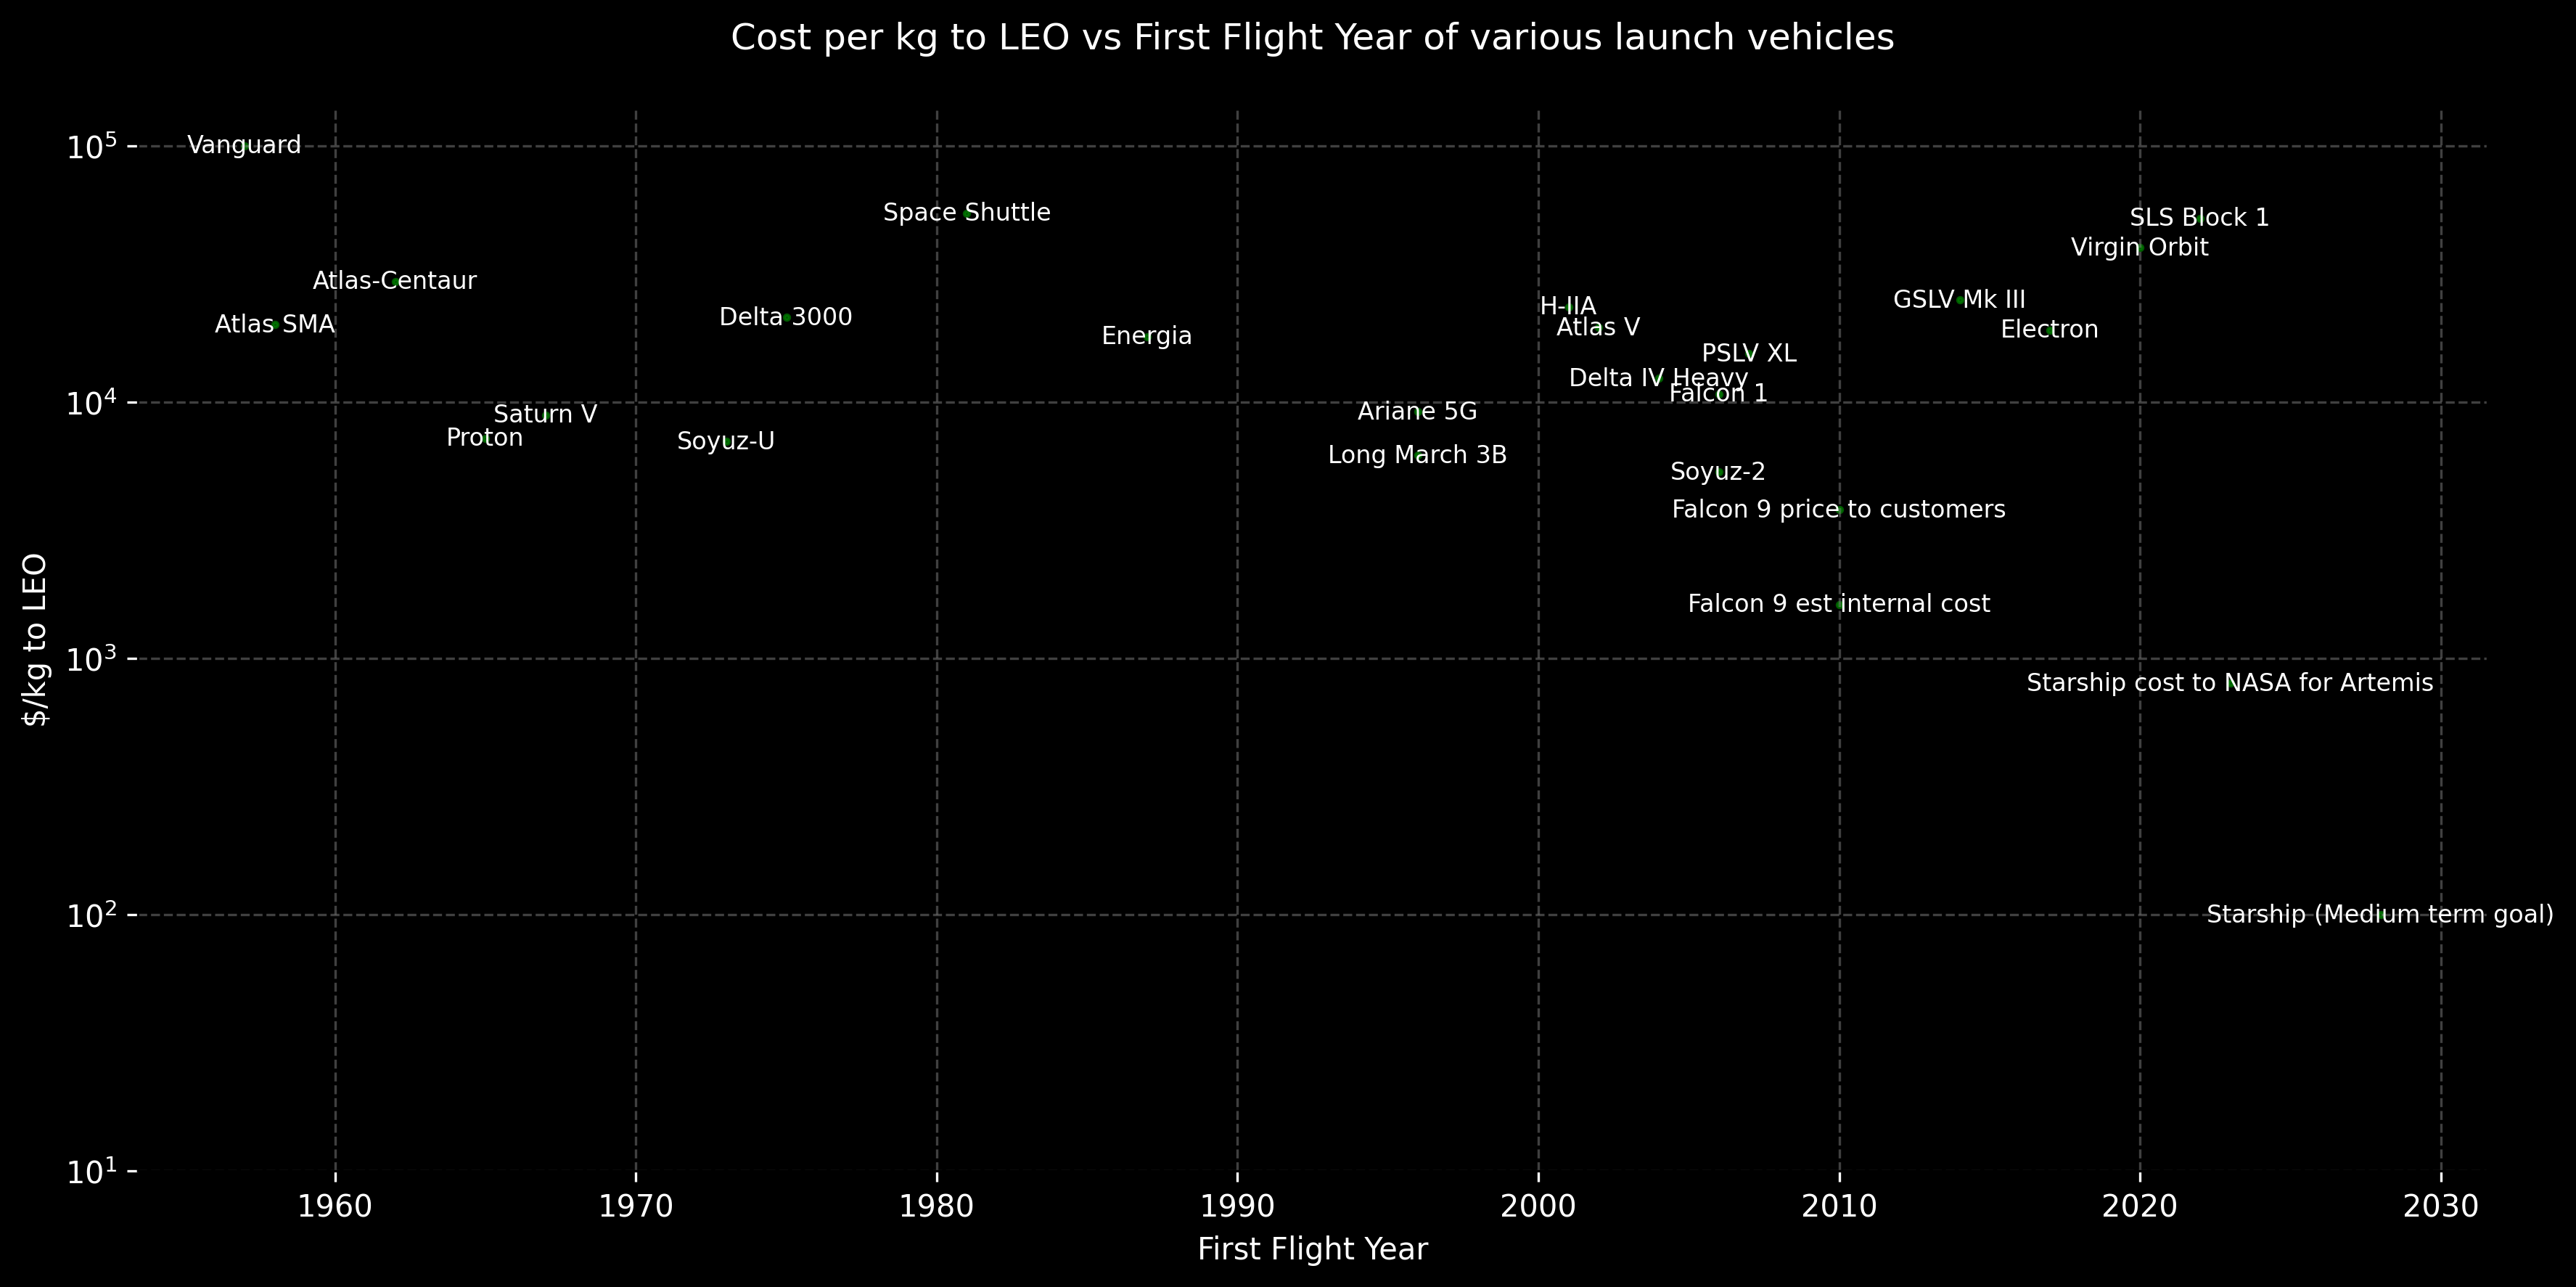

In [4]:

import matplotlib.pyplot as plt

# Data without N1, constant bubble size
rockets = [
    "Vanguard", "Atlas SMA", "Atlas-Centaur", "Saturn V", "Delta 3000","Space Shuttle", "Energia",
    "Proton", "Soyuz-2", "Falcon 1", "Delta IV Heavy", "Atlas V", "Ariane 5G",
    "Long March 3B", "PSLV XL", "H-IIA", "GSLV Mk III", "Electron", 
    "Virgin Orbit", "Falcon 9 price to customers", "Falcon 9 est internal cost", "SLS Block 1", "Starship cost to NASA for Artemis","Starship (Medium term goal)", "Soyuz-U"
]

# rockets = [
#     "Vanguard", "Atlas-Centaur","Saturn V","Space Shuttle", "Soyuz-2", "Atlas V",
#      "Falcon 9", "Falcon Heavy B5", "SLS Block 1", "Starship", "Ariane 5"
# ]

first_flight = [
    1957, 1958, 1962, 1967, 1975, 1981, 1987,
    1965, 2006, 2006, 2004, 2002, 1996,
    1996, 2007, 2001, 2014, 2017, 2020,
    2010, 2010, 2022, 2023, 2028, 1973 
]

# first_flight = [
# 1958, 1962, 1967, 1981, 2006, 2002,
# 2010, 2019, 2022, 2023, 1996
# ]

cost_per_kg = [
    100000, 20000, 29500, 8900, 21400, 54500, 18000,
    7220, 5333, 10754, 12340, 19500, 9167,
    6200, 15450, 23500, 25000, 19039, 40000,
    3800, 1620, 52100, 800, 100, 7000
]

# cost_per_kg = [
#     100000,20000, 8900,  54500, 5340 ,19500,
#     1820, 1500, 52100, 100, 9200
# ]

# Create bubble chart with constant size
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

constant_size = 3  # constant bubble size for all

ax.scatter(first_flight, cost_per_kg, s=constant_size, color='green', alpha=0.7)

# Centered annotations
for x, y, label in zip(first_flight, cost_per_kg, rockets):
    ax.text(x, y, label, fontsize=8, ha='center', va='center', color='white')

# Styling
ax.set_xlabel("First Flight Year", color='white')
ax.set_ylabel("$/kg to LEO", color='white')
ax.set_title("Cost per kg to LEO vs First Flight Year of various launch vehicles\n", color='white')
ax.set_yscale('log')
ax.grid(True, color='gray', linestyle='--', alpha=0.5)
ax.tick_params(colors='white')

# # Highlight "Starship" label
# starship_idx = rockets.index("Starship")
# x_starship = first_flight[starship_idx]
# y_starship = cost_per_kg[starship_idx]

# ax.annotate(
#     "★ Starship",
#     xy=(x_starship, y_starship),
#     xytext=(x_starship+2, y_starship*1.5),
#     color='yellow',
#     fontsize=14,
#     fontweight='bold',
#     arrowprops=dict(facecolor='yellow', arrowstyle='->'),
#     ha='left'
# )
plt.ylim(bottom=10)

plt.tight_layout()
plt.show()


In [5]:
from io import BytesIO
from PIL import Image
# Open an image from a computer 
def open_image_local(path_to_image):
    image = Image.open(path_to_image) # Open the image
    image_array = np.array(image) # Convert to a numpy array
    return image_array # Output

I'm taking the LEO payload of the rocket as the maximum amount of excess propellant in the tanks of the upper stage once it reaches orbit

In [6]:
# performance = { 'Rocket': [wet mass (kg), dry mass (kg), vacuum Isp (s)] }
performance = {
    # [wet_mass_kg, dry_mass_kg, Isp_s, LEO_payload_kg]
    'Atlas-Centaur':            [17400, 2030, 444,   4500],   # classic Atlas SLV-3D / Centaur D-1A
    'Titan IV-B Centaur':       [23300, 2800, 449,   21680],  # Titan IV-B with Centaur T upper stage
    'Atlas V 551':              [23077, 2247, 449.7,   18850],
    'Falcon 9 RTLS':        [111500, 4200, 348,    15000],   # fully‑fuelled second stage
    'Falcon 9 expended':        [111500, 4200, 348,    22800],   # fully‑fuelled second stage
    'Falcon Heavy expended':    [111500, 4200, 348,  63800],
    'Delta IV Heavy':           [30700,  3480, 465.5,  28790],
    'SLS Block 1B':             [143000,  14000, 460, 105000],
    'Saturn V':[123000,13500,420,145000],
    'Unrefuelled Starship':[1300000,120000,380,250000],
    'Starship refuelled in LEO':[1300000,120000,380,  1450000],
    'Starship refuelled in HEO':[1300000,120000,380,  1450000],
    'Light Starship refuelled in HEO':[1300000,80000,380,  1450000],
}
# #all assume starting in orbit with periapsis of 200km, but have some DV penalty/bonus from use of upper stage to reach LEO/HEO Starship & SLS bonus
# performance = {
#     # [wet_mass_kg, dry_mass_kg, Isp_s, LEO_payload_kg]
#     'Atlas V 551':              [23077, 2247, 449.7,   18850],
#     # 'Falcon 9 expended':        [111500, 4000, 348,    22800],   # fully‑fuelled second stage
#     # 'Falcon Heavy expended':    [111500, 4000, 348,    63800],
#     # 'Delta IV Heavy':           [30700,  3480, 465.5,  28790],
#     # 'SLS Block 1B':             [143000,  14000, 460, 105000],
#     'Unrefuelled Starship':[1300000,120000,380,250000],
#     'Starship refuelled in LEO':[1300000,120000,380,  1450000],
#     # 'Starship refuelled in HEO':[1300000,120000,380,  1450000],
#     'Stripped Starship refuelled in HEO':[1300000,80000,380,  1450000],
# }    

performance_short_old = {
    # [wet_mass_kg, dry_mass_kg, Isp_s, LEO_payload_kg]
    'Titan IV-B Centaur':       [23300, 2800, 449,   21680],  # Titan IV-B with Centaur T upper stage
    'Atlas V 551':              [23077, 2247, 449.7,   18850],
    'Saturn V':[123000,13500,420,145000],
    'Falcon 9 expended':        [111500, 4200, 348,    22800],
    'Starship refuelled in LEO':[1300000,120000,380,  1450000],
}

Need to calculate the payload mass of various rockets as a function of C3. C3 is the energy given as:
$$
\frac{C_3}{2}=\frac{v^2}{2}-\frac{\mu}{r}
$$
This is only positive for objects on escape velocity trajectories. Once we know the DV of the spacecraft, it is easy to calculate this number numerically starting from HEO (eg SLS or Starship) or analytically from LEO (even easier). The issue is that for all vehicles that do not utilize in orbit refuelling, the LEO/HEO DV is a function of payload mass, and this is not publically avaliable info. We can make a first pass assuming that the second stage reaches orbit with propellant roughly equal to the vehicles max LEO payload minus the actual payload mass. 

<!-- We can make a first pass assuming constant DV to reach orbit (not a terrible assumption since all listed vehicles have reasonably high TWR, so gravity losses are reduced) -->

The only major problem is SLS as LEO payload > 2nd stage prop mass for block 1. I suppose I could just do B1B. 


In [7]:
#Light DV calc
isp = 380.5 #348 mvac, 380 rvac, 421 j2, 450.5 Rl10
payload = 122000
dry_mass = 122050#dry mass of upper stage not including payload
max_payload_leo = 1500000
dv = 9.81*isp*np.log((max_payload_leo+dry_mass)/(payload+dry_mass))
print(f"{dv}m/s")


7070.0155260658585m/s


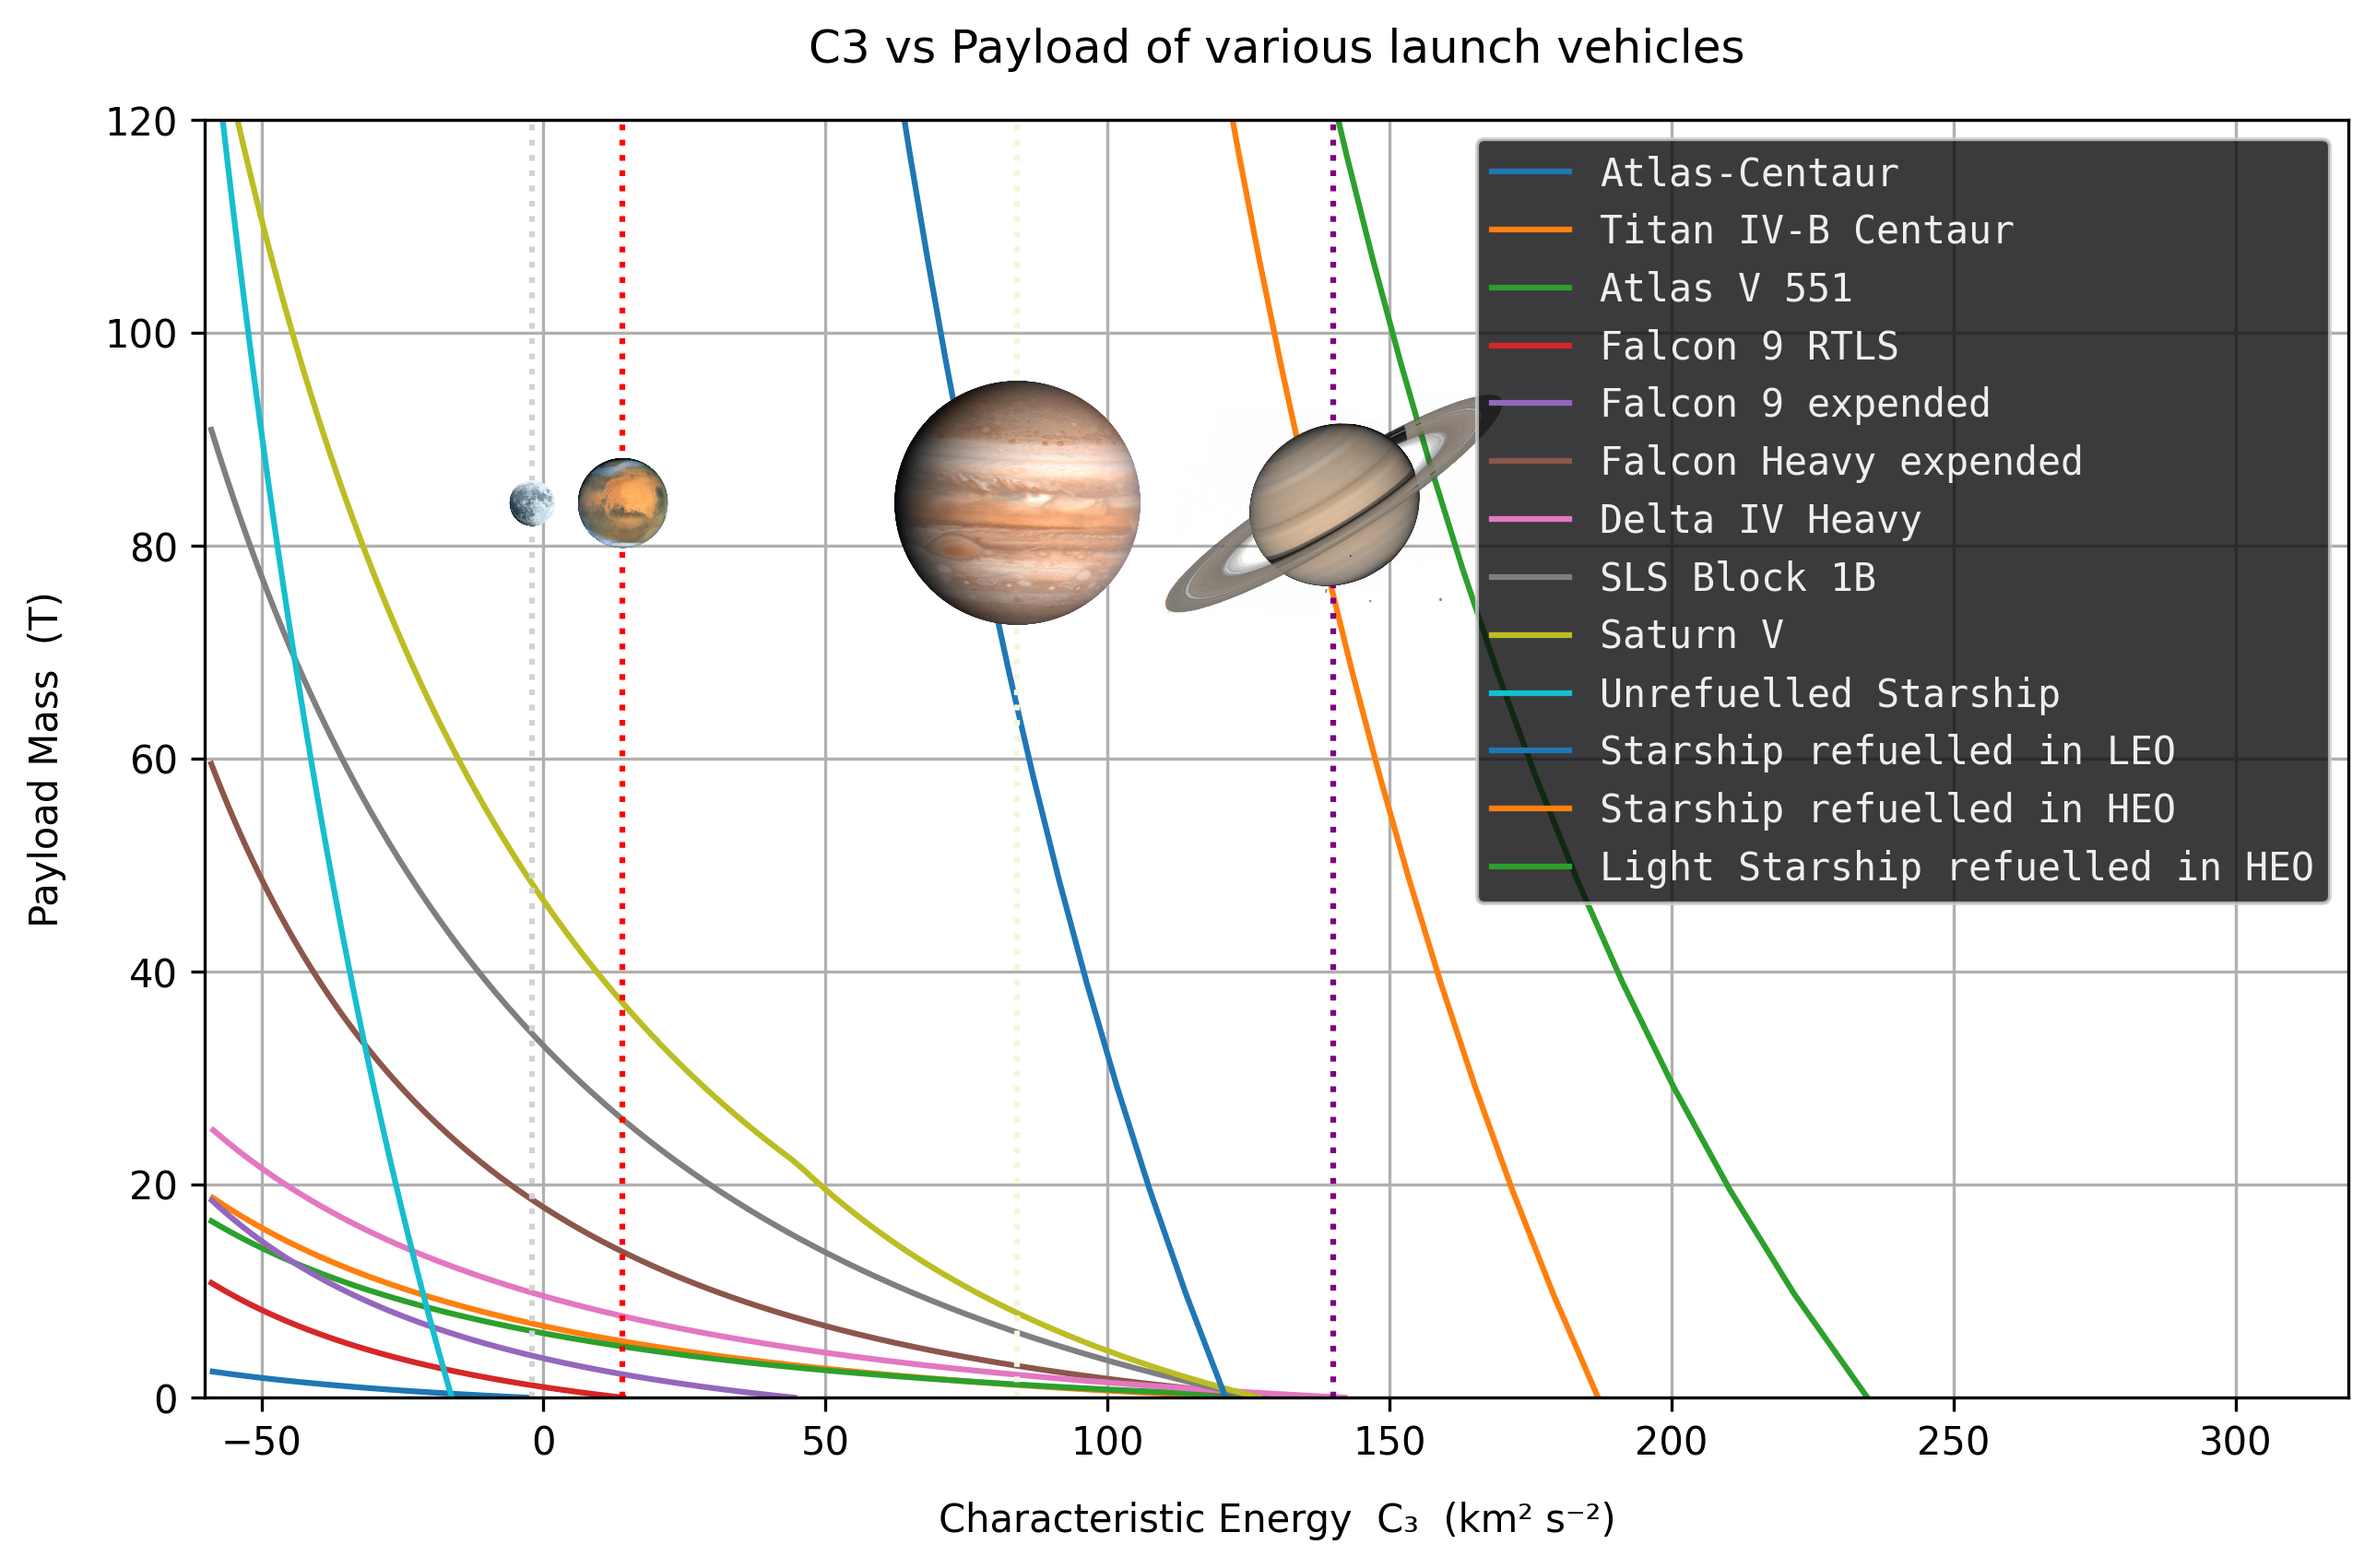

In [8]:
g0 = 9.80665  # m/s^2
v_leo = 7780  # m/s (circular velocity at ~200 km)
v_escape = 10930  # m/s (escape velocity at same altitude)

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background') # Start with a dark base

# ----------  Retro‑Sci‑Fi Matplotlib Theme  ----------
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

for lv, (wet_mass, dry_mass, isp, leo_cap) in performance.items():
    prop_capacity = wet_mass - dry_mass
    # sample 150 points between a small payload (1 kg) and the LEO capability
    payloads = np.linspace(1, leo_cap, 150)
    c3_vals = []
    valid_payloads = []
    for p in payloads:
        available_prop = leo_cap - p - dry_mass
        # cap by tank capacity and ignore negative available propellant
        if available_prop <= 0:
            continue
        available_prop = min(available_prop, prop_capacity)
        delta_v = 0.87*isp * g0 * np.log((available_prop+dry_mass+p)/ (dry_mass + p))
        if lv == 'Starship refuelled in HEO' or lv == 'Light Starship refuelled in HEO':
            delta_v += 2000
        c3 = (v_leo + delta_v)**2 - v_escape**2  # m^2/s^2
        c3_vals.append(c3 / 1e6)  # convert to km^2/s^2
        valid_payloads.append(p/1e3)
    if c3_vals:
        ax.plot(c3_vals, valid_payloads, label=lv)


def imscatter(x, y, image, ax=None, zoom=1):
    if ax is None:
        ax = plt.gca()
    try:
        image = plt.imread(image)
    except TypeError:
        # Likely already an array...
        pass
    im = OffsetImage(image, zoom=zoom)
    x, y = np.atleast_1d(x, y)
    artists = []
    for x0, y0 in zip(x, y):
        ab = AnnotationBbox(im, (x0, y0), xycoords='data', frameon=False)
        artists.append(ax.add_artist(ab))
    ax.update_datalim(np.column_stack([x, y]))
    ax.autoscale()
    return artists


# Axis labels and title with retro flavour
ax.set_xlabel('Characteristic Energy  C₃  (km² s⁻²)', labelpad=10)
ax.set_ylabel('Payload Mass  (T)', labelpad=10)
plt.title('C3 vs Payload of various launch vehicles')
ax.grid(True)
# #ax.tight_layout()
plt.axvline(x = -2, linestyle='dotted', color = 'lightgray')
plt.axvline(x = 14, linestyle='dotted', color = 'red')
plt.axvline(x = 84, linestyle='dotted', color = 'beige')
plt.axvline(x = 140, linestyle='dotted', color = 'purple')
add_planet_on_c3(ax, -2, "pngtree-detailed-full-moon-rendered-in-3d-for-creative-use-png-image_15976807.png", y_frac=0.70, zoom=0.040)
add_planet_on_c3(ax, 140, "saturn.png",  y_frac=0.70, zoom=0.062)  # lower to dodge legend, rings fit
add_planet_on_c3(ax, 14, "mars.png",  y_frac=0.70, zoom=0.052)  # lower to dodge legend, rings fit
add_planet_on_c3(ax, 84, "jupiter.png",  y_frac=0.70, zoom=0.082)  # lower to dodge legend, rings fit

# plt.axhline(y=9000)
# plt.axhline(y=16800)

ax.legend(loc='upper right')
plt.xlim(left = -60,right=320)
plt.ylim(top = 120,bottom = 0)
plt.show()

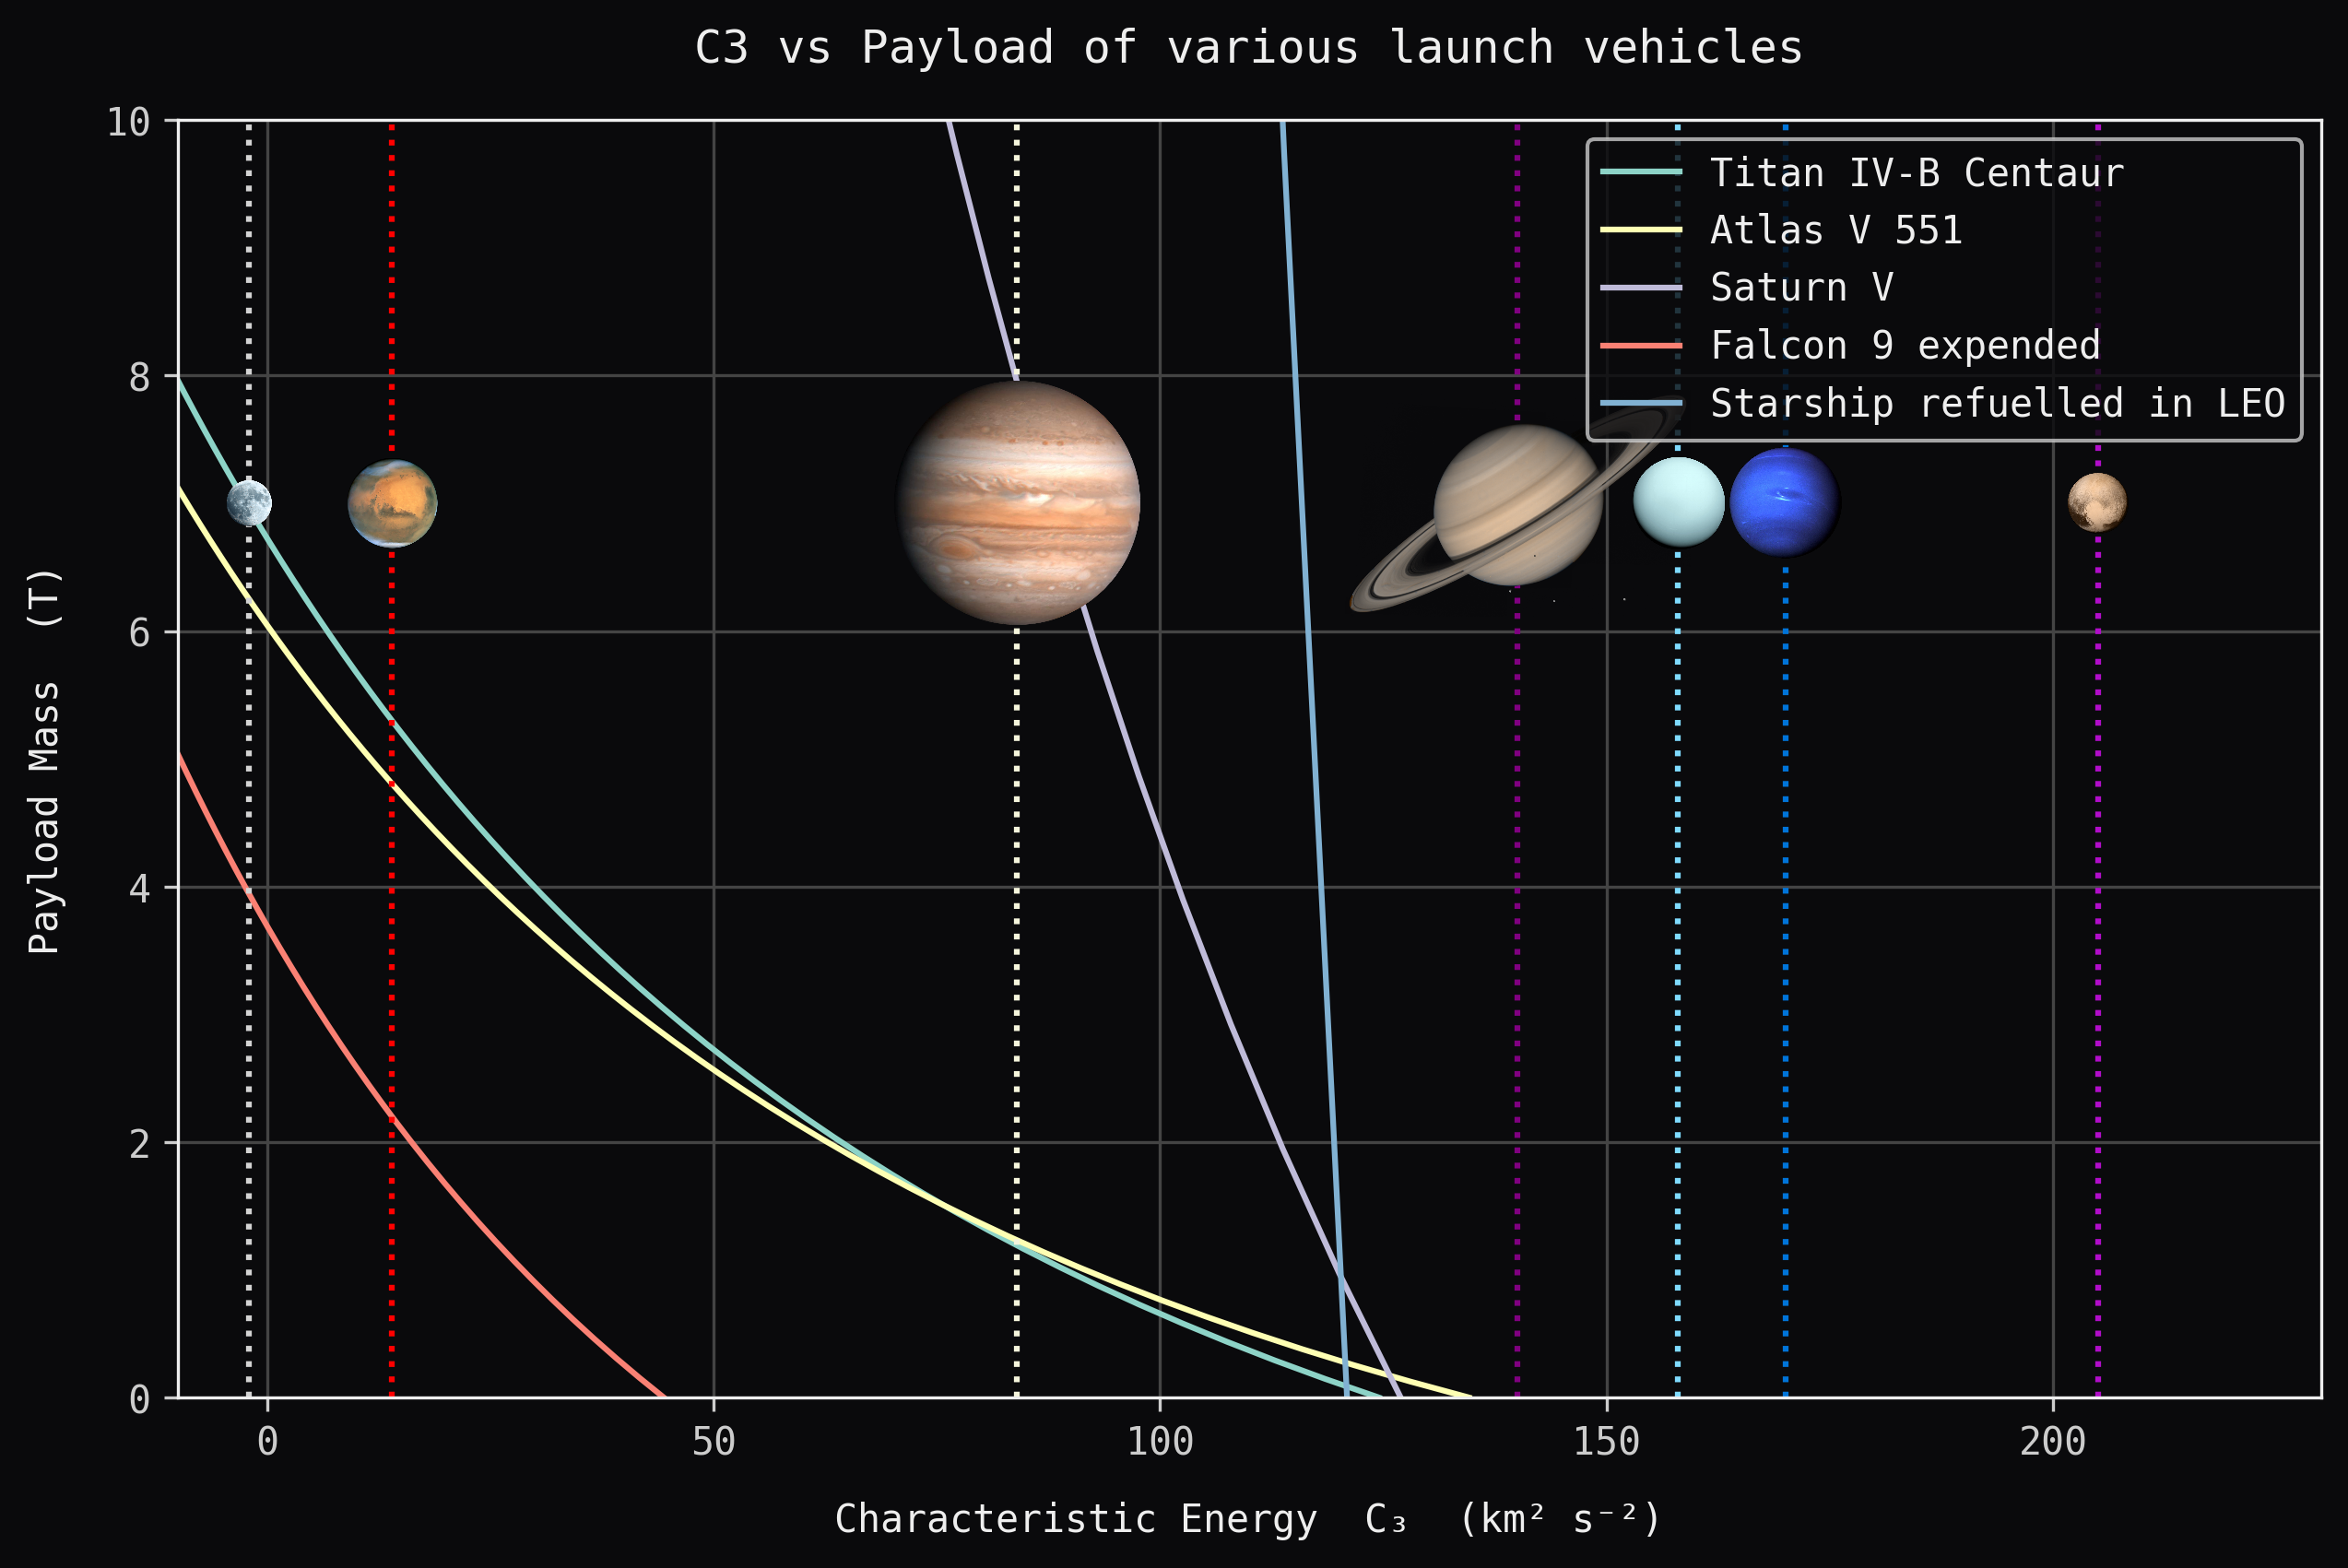

In [9]:
#with all the planets
g0 = 9.80665  # m/s^2
v_leo = 7780  # m/s (circular velocity at ~200 km)
v_escape = 10930  # m/s (escape velocity at same altitude)

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background')

# ----------  Retro‑Sci‑Fi Matplotlib Theme  ----------
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

for lv, (wet_mass, dry_mass, isp, leo_cap) in performance_short_old.items():
    prop_capacity = wet_mass - dry_mass
    payloads = np.linspace(1, leo_cap, 150)
    c3_vals = []
    valid_payloads = []
    for p in payloads:
        available_prop = leo_cap - p - dry_mass
        if available_prop <= 0:
            continue
        available_prop = min(available_prop, prop_capacity)
        delta_v = 0.87*isp * g0 * np.log((available_prop+dry_mass+p)/ (dry_mass + p))
        if lv == 'Starship refuelled in HEO' or lv == 'Light Starship refuelled in HEO':
            delta_v += 2000
        c3 = (v_leo + delta_v)**2 - v_escape**2  # m^2/s^2
        c3_vals.append(c3 / 1e6)
        valid_payloads.append(p/1e3)
    if c3_vals:
        ax.plot(c3_vals, valid_payloads, label=lv)

ax.set_xlabel('Characteristic Energy  C₃  (km² s⁻²)', labelpad=10)
ax.set_ylabel('Payload Mass  (T)', labelpad=10)
plt.title('C3 vs Payload of various launch vehicles')
ax.grid(True)

# Moon + inner-system / Saturn markers
plt.axvline(x=-2,  linestyle='dotted', color='lightgray')
plt.axvline(x=14,  linestyle='dotted', color='red')
plt.axvline(x=84,  linestyle='dotted', color='beige')
plt.axvline(x=140, linestyle='dotted', color='purple')
add_planet_on_c3(ax, -2,  "pngtree-detailed-full-moon-rendered-in-3d-for-creative-use-png-image_15976807.png", y_frac=0.70, zoom=0.040)
add_planet_on_c3(ax, 140, "saturn.png",  y_frac=0.70, zoom=0.062)
add_planet_on_c3(ax, 14,  "mars.png",    y_frac=0.70, zoom=0.052)
add_planet_on_c3(ax, 84,  "jupiter.png", y_frac=0.70, zoom=0.082)

# Outer planets — direct ballistic Hohmann-ish C3 values (km²/s²)
plt.axvline(x=158, linestyle='dotted', color='#7FDBFF')   # Uranus
plt.axvline(x=170, linestyle='dotted', color='#0074D9')   # Neptune
plt.axvline(x=205, linestyle='dotted', color='#B10DC9')   # Pluto
add_planet_on_c3(ax, 158, "Transparent_Uranus.png", y_frac=0.70, zoom=0.040)
add_planet_on_c3(ax, 170, "Neptune_cutout.png",     y_frac=0.70, zoom=0.015)
add_planet_on_c3(ax, 205, "Pluto-transparent.png",  y_frac=0.70, zoom=0.025)

ax.legend(loc='upper right')
plt.xlim(left=-10, right=230)
plt.ylim(top=10, bottom=0)
plt.show()


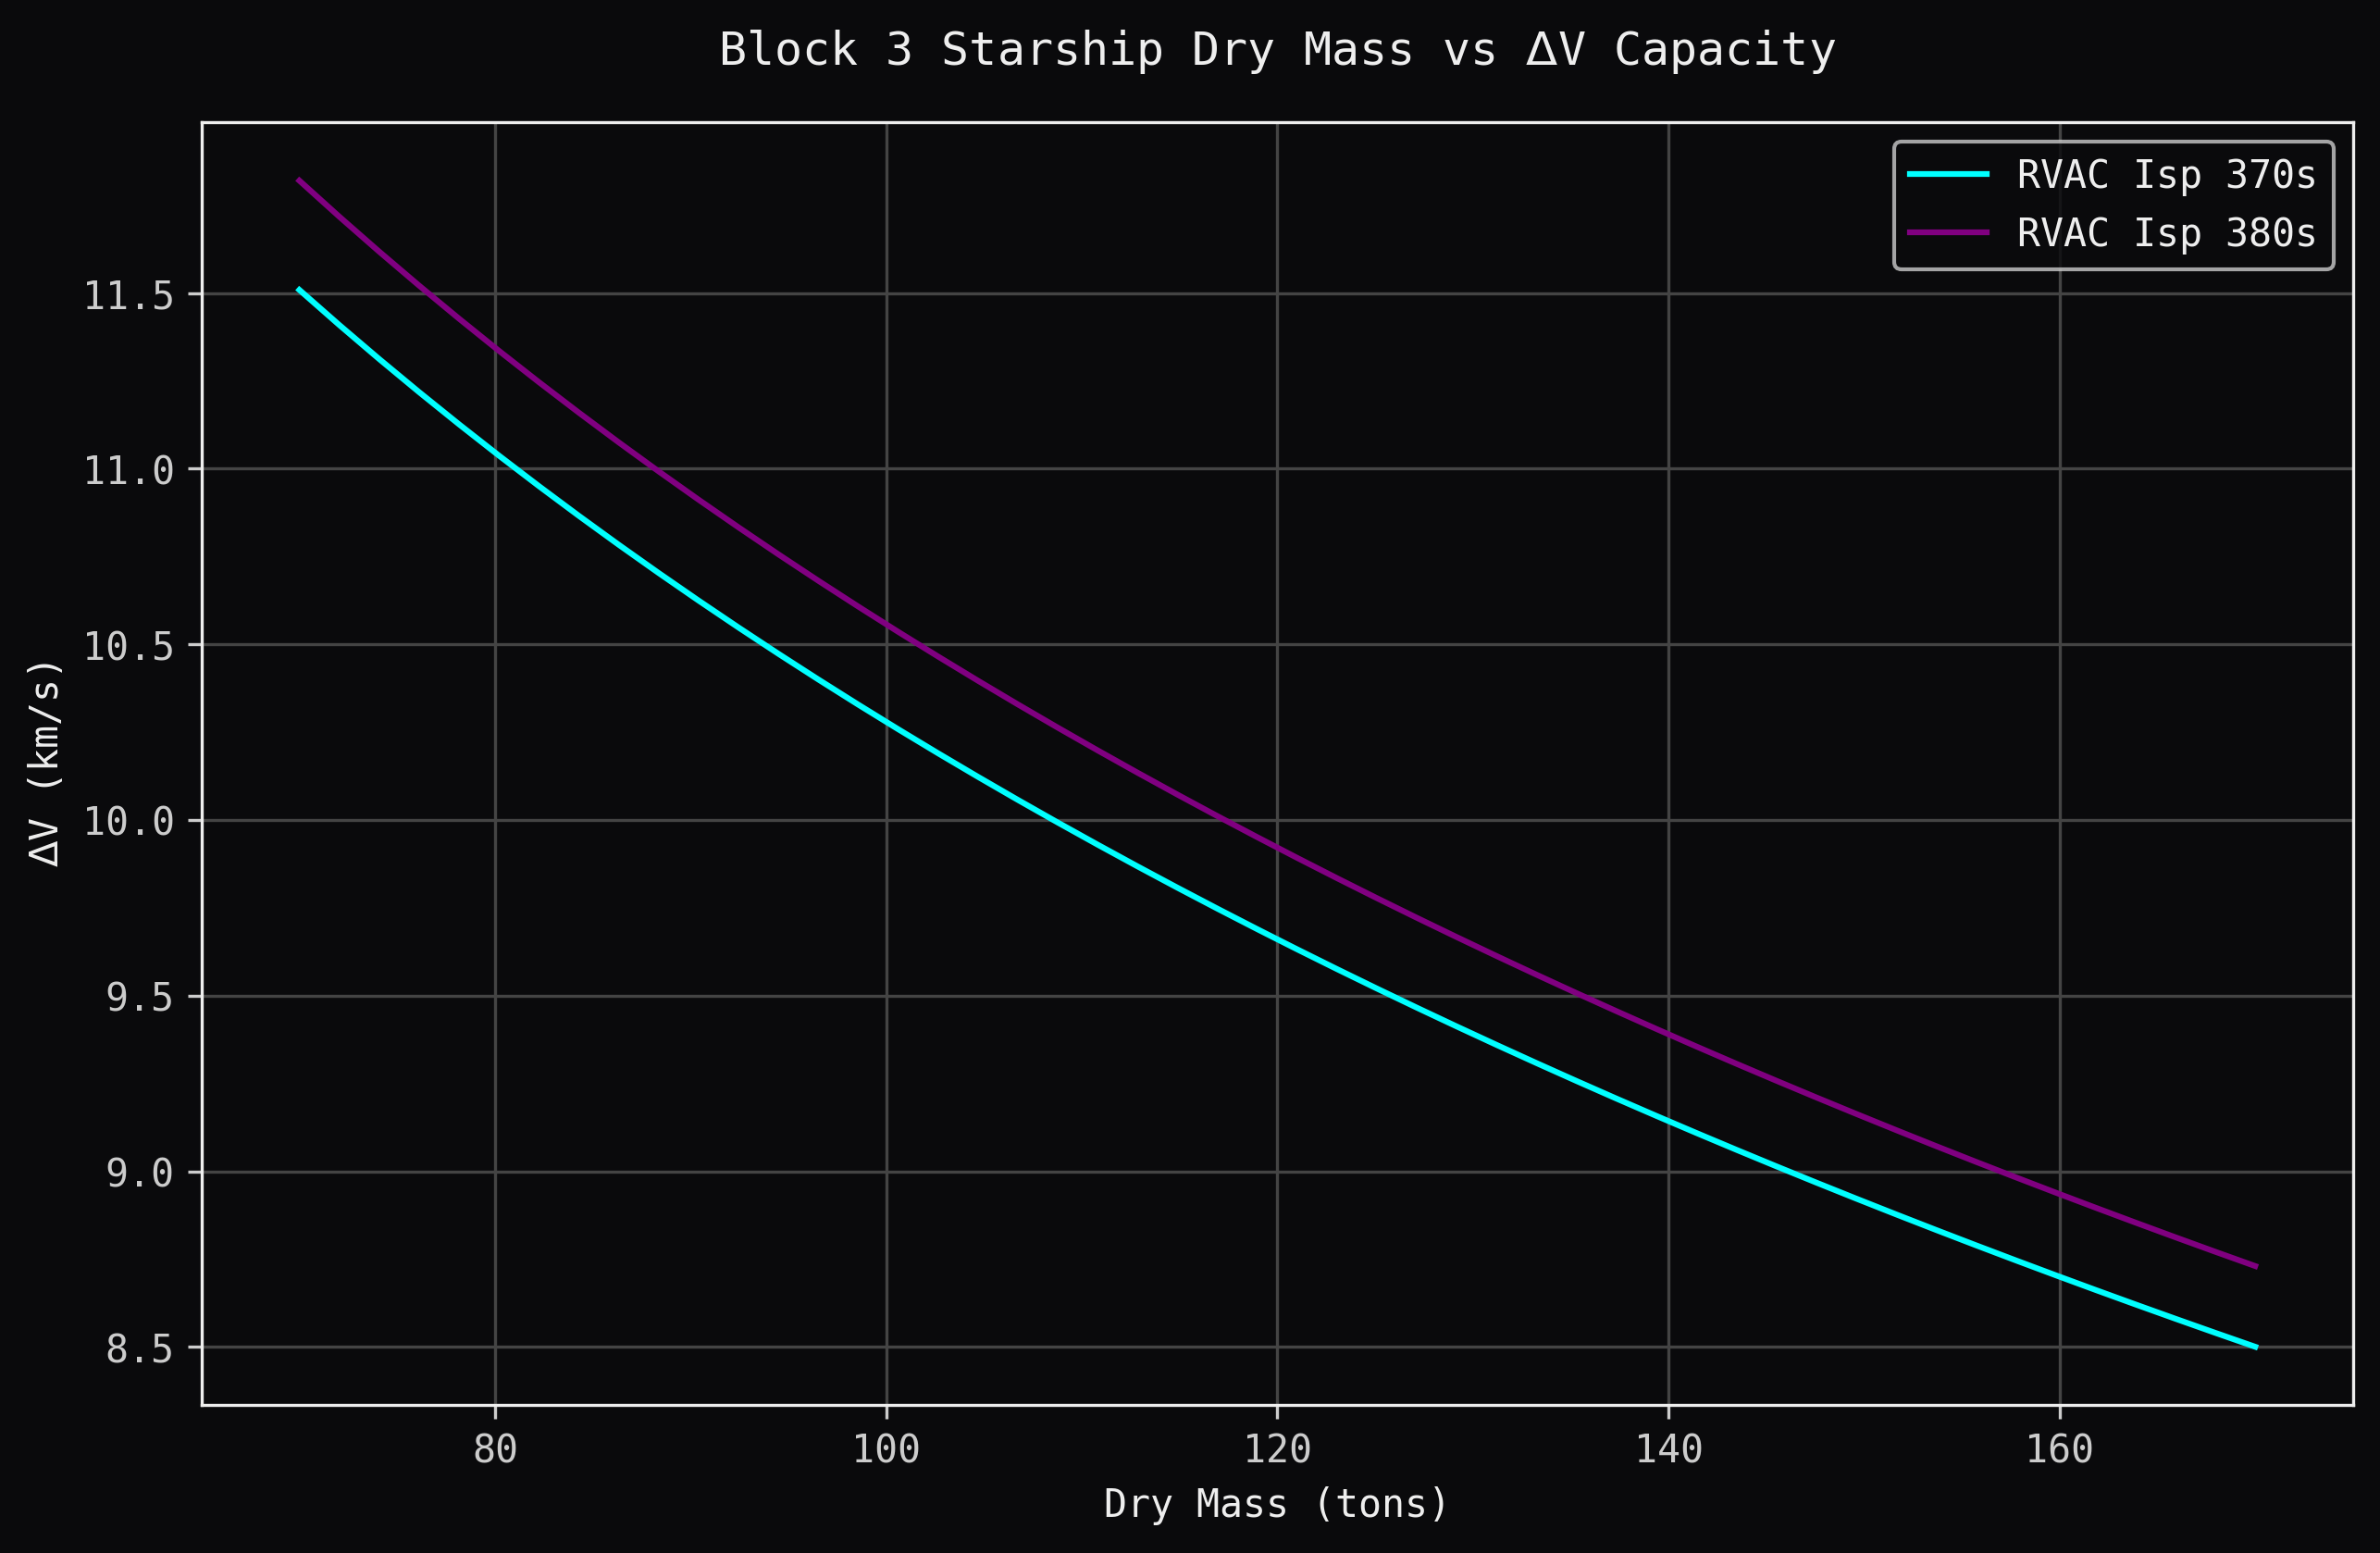

Dry mass of 123.06T gets you 9.6km/s of DV


In [10]:
prop_load = 1600
dry_mass = np.linspace(70,170,50)
dv_1 = 9.806*370*np.log((prop_load+dry_mass)/dry_mass)*1e-3
dv_2 = 9.806*380*np.log((prop_load+dry_mass)/dry_mass)*1e-3

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background') # Start with a dark base

# ----------  Retro‑Sci‑Fi Matplotlib Theme  ----------
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

ax.plot(dry_mass, dv_1, label='RVAC Isp 370s', color='cyan')
ax.plot(dry_mass, dv_2, label='RVAC Isp 380s', color='purple')
ax.grid(True)


ax.legend(loc='upper right')

plt.title("Block 3 Starship Dry Mass vs $\Delta$V Capacity")
plt.xlabel("Dry Mass (tons)")
plt.ylabel("$\Delta$V (km/s)")
plt.show()

target_dv=9.6
idx=np.argmin(np.abs(dv_1-target_dv))
print(f"Dry mass of {dry_mass[idx]:.2f}T gets you {target_dv}km/s of DV")


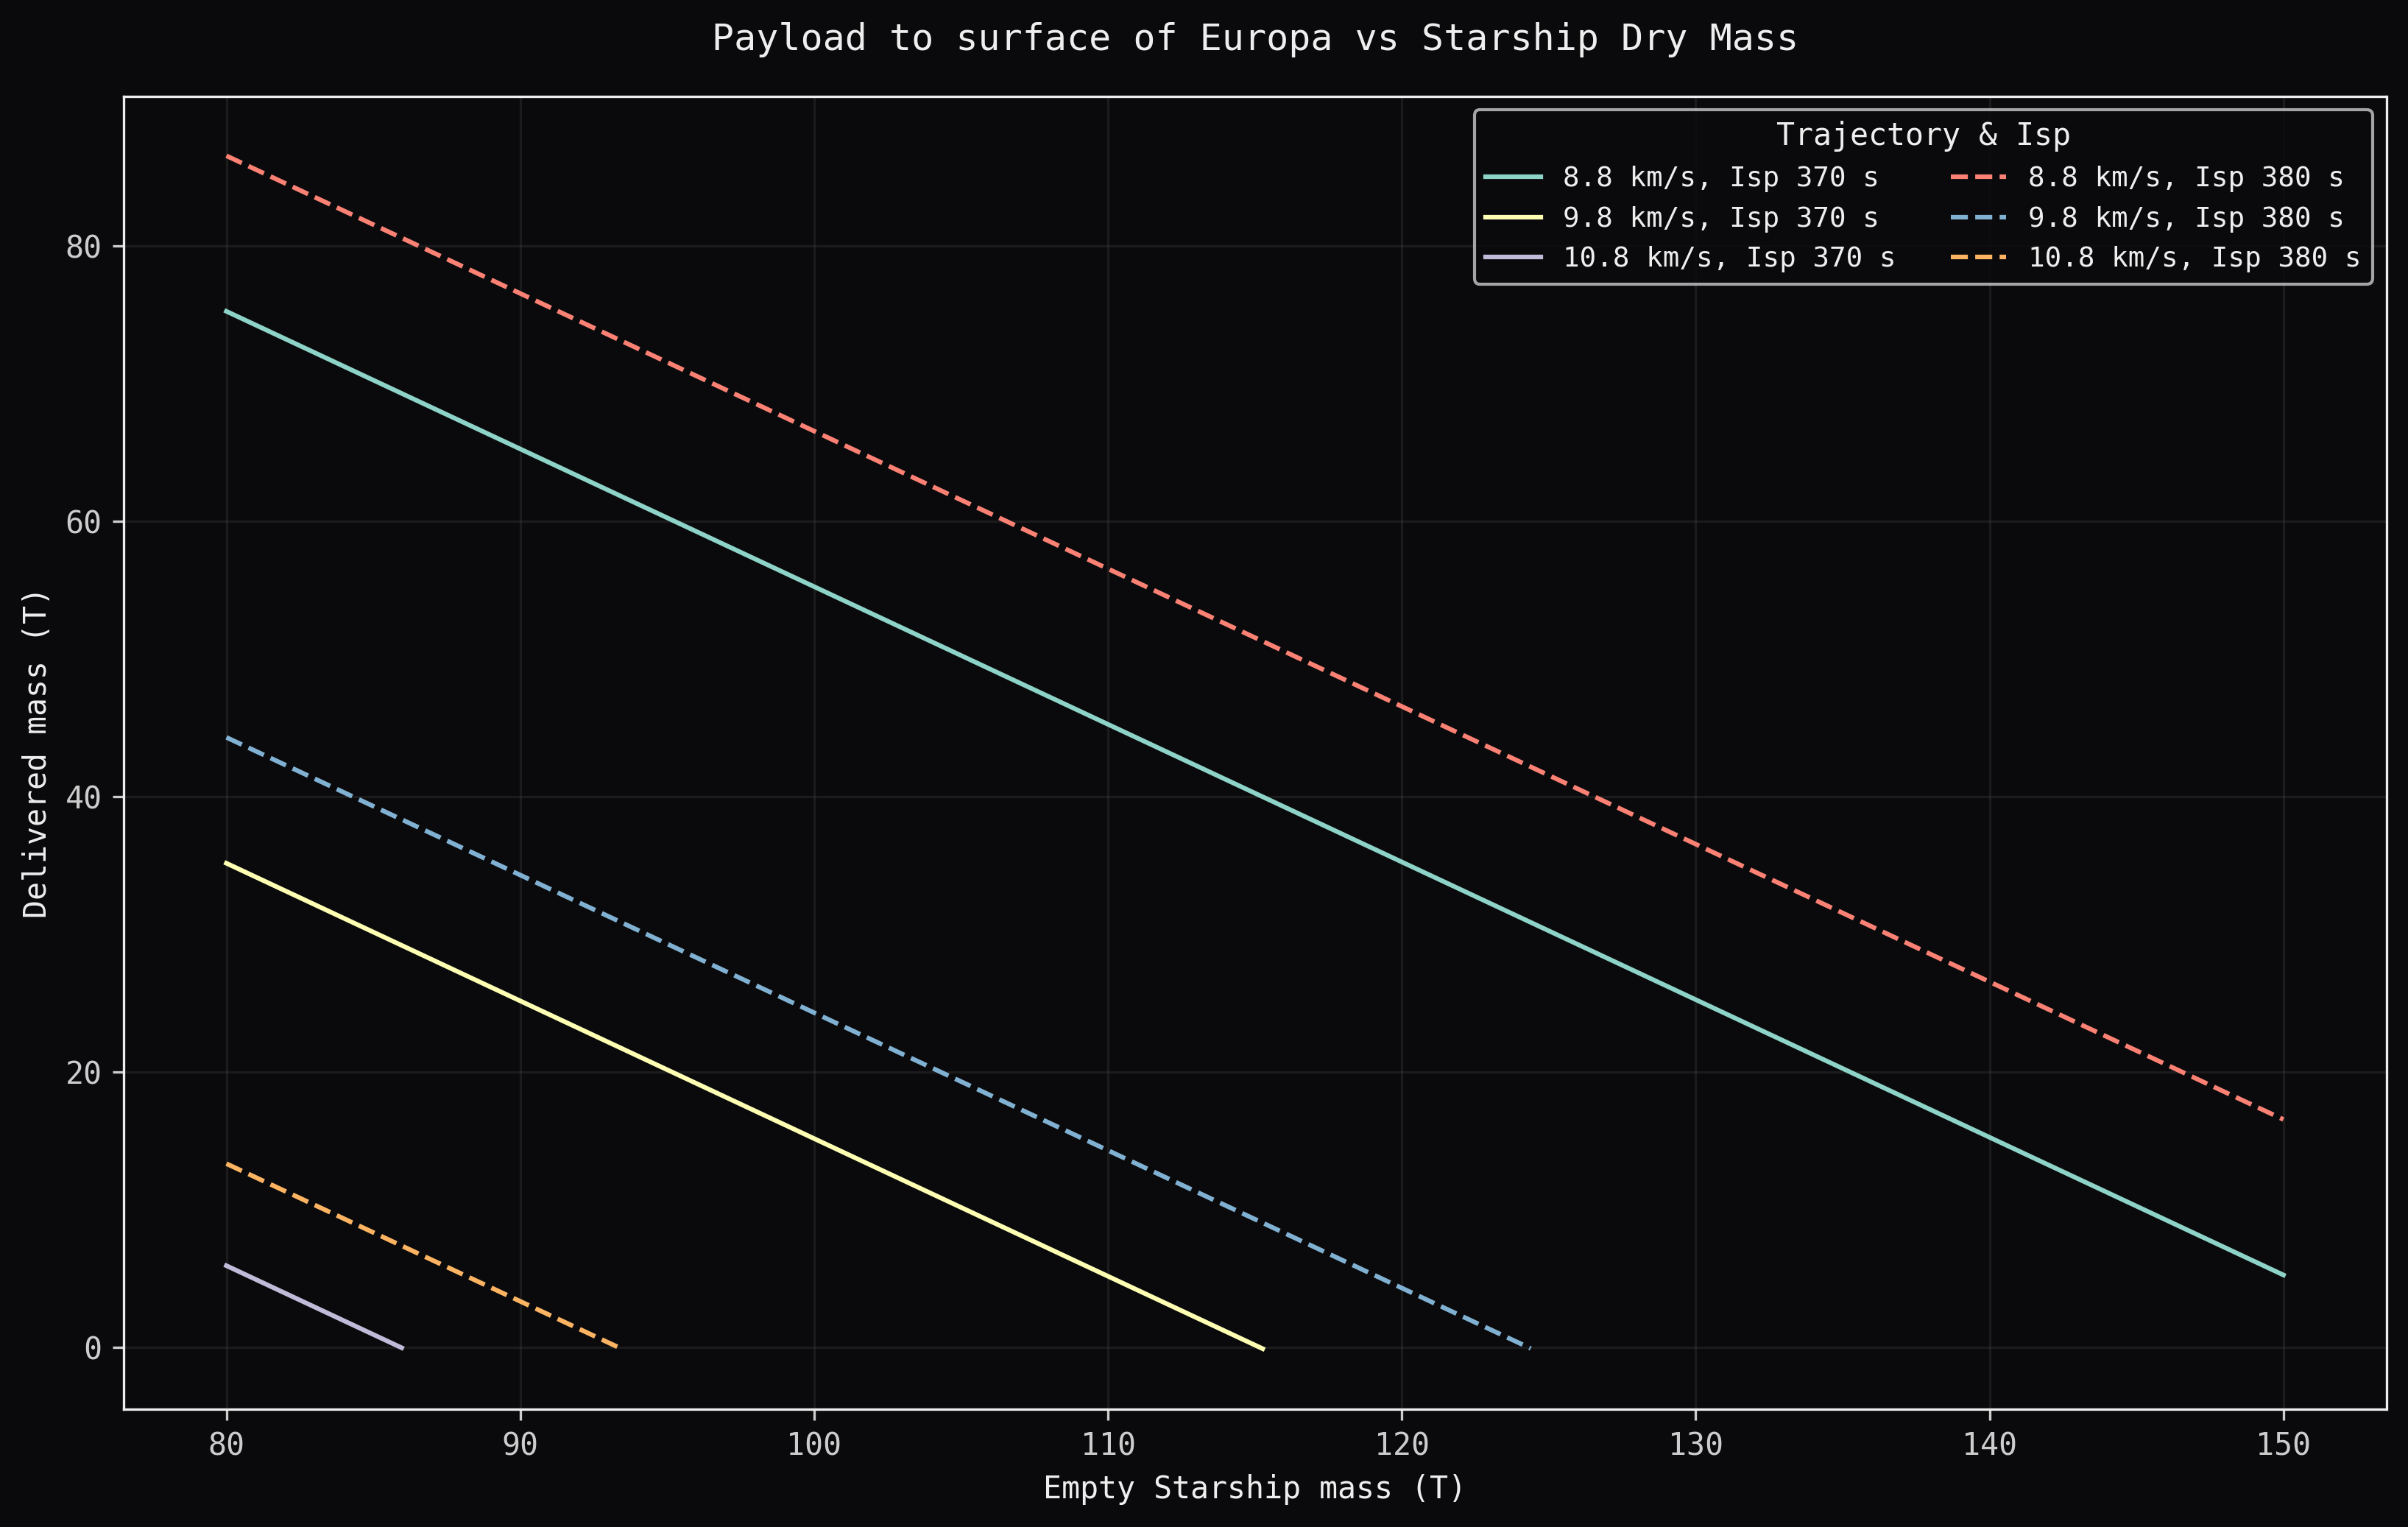

In [11]:
import numpy as np
import matplotlib.pyplot as plt

g0 = 9.80665  # m/s^2

# Updated assumptions
m_prop_t = 1600.0                 # tonnes usable propellant
isp_list = [370.0, 380.0]         # s
# isp_list = [370.0]

dv_kms_list = [8.8, 9.8, 10.8]    # km/s

# Dry mass sweep (tonnes)
m_dry = np.linspace(80, 150, 400)

def payload_delivered(m_dry_t, dv_kms, Isp_s, m_prop_t=m_prop_t):
    """Payload (tonnes) delivered for a given dry mass and delta-v, using rocket equation."""
    R = np.exp((dv_kms * 1000.0) / (g0 * Isp_s))  # mass ratio m0/mf
    return (m_prop_t / (R - 1.0)) - m_dry_t       # payload (can go negative)

plt.figure(figsize=(11, 7))

# Plot style: different line styles for Isp, different colors for dv
linestyles = {370.0: "-", 380.0: "--"}
# linestyles = {370.0: "-"}

for Isp_s in isp_list:
    for dv in dv_kms_list:
        y = payload_delivered(m_dry, dv, Isp_s)

        # End the line where payload first becomes negative (do not clip to 0)
        neg_idx = np.where(y < 0)[0]
        if len(neg_idx) > 0:
            cut = neg_idx[0]
            x_plot = m_dry[:cut+1]
            y_plot = y[:cut+1]
        else:
            x_plot = m_dry
            y_plot = y

        plt.plot(
            x_plot, y_plot,
            linestyle=linestyles[Isp_s],
            label=f"{dv:.1f} km/s, Isp {Isp_s:.0f} s"
        )

plt.xlabel("Empty Starship mass (T)")
plt.ylabel("Delivered mass (T)")
plt.title("Payload to surface of Europa vs Starship Dry Mass")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9, title="Trajectory & Isp")
plt.tight_layout()
plt.show()



In [12]:
##
dv_used_pre_landing=7.43#8.83
dm=120
payload=10

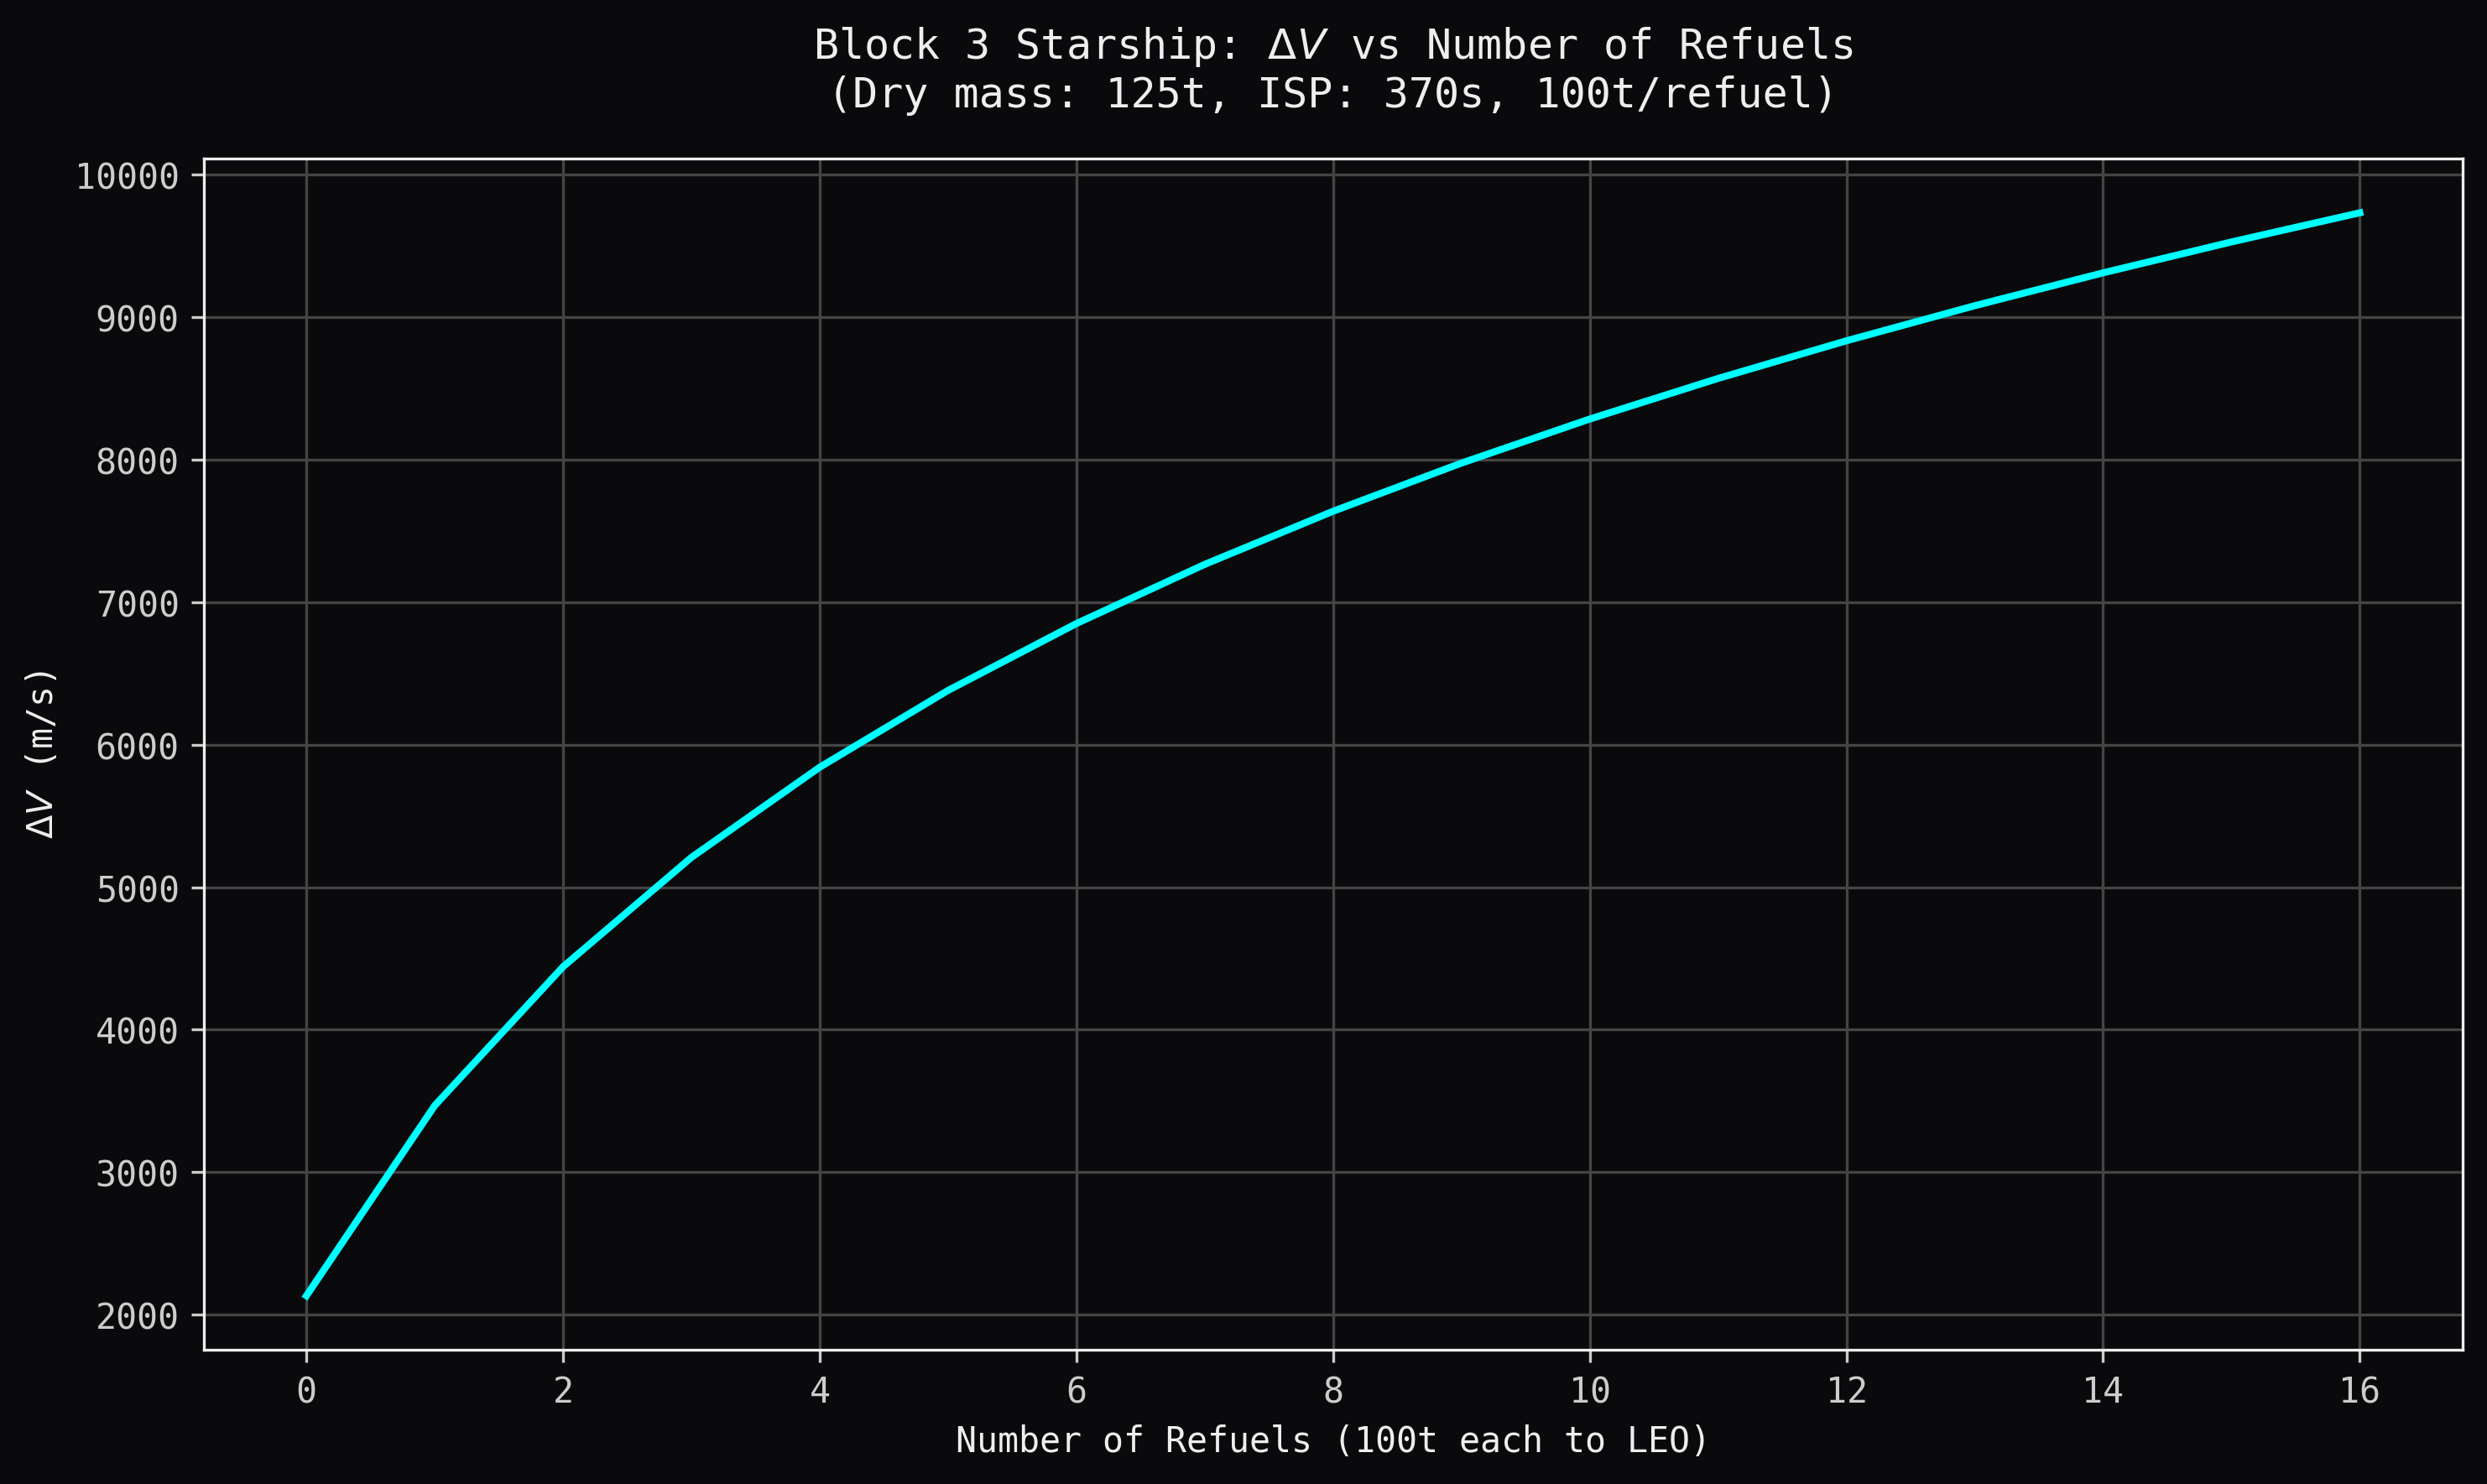

In [13]:
#Starship refuels v DV
from matplotlib.ticker import MaxNLocator

dry_mass = 125       # tonnes (Block 3)
isp = 370             # seconds
tanker_prop = 100     # tonnes delivered to LEO per refuel
total_prop = 1600
g0 = 9.81

max_refuels = int(total_prop / tanker_prop)     # 16 x 100t = 1600t full tank
n_refuels = np.arange(0, max_refuels + 1)
prop_mass = 100+n_refuels * tanker_prop
dv = isp * g0 * np.log((dry_mass + prop_mass) / dry_mass)

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.plot(n_refuels, dv, color='cyan', linewidth=2, markersize=6)
ax.grid(True)



ax.set_xlabel(f"Number of Refuels ({tanker_prop}t each to LEO)")
ax.set_ylabel("$\\Delta V$ (m/s)")
ax.set_title(f"Block 3 Starship: $\\Delta V$ vs Number of Refuels\n(Dry mass: {dry_mass}t, ISP: {isp}s, {tanker_prop}t/refuel)")
plt.tight_layout()
plt.show()

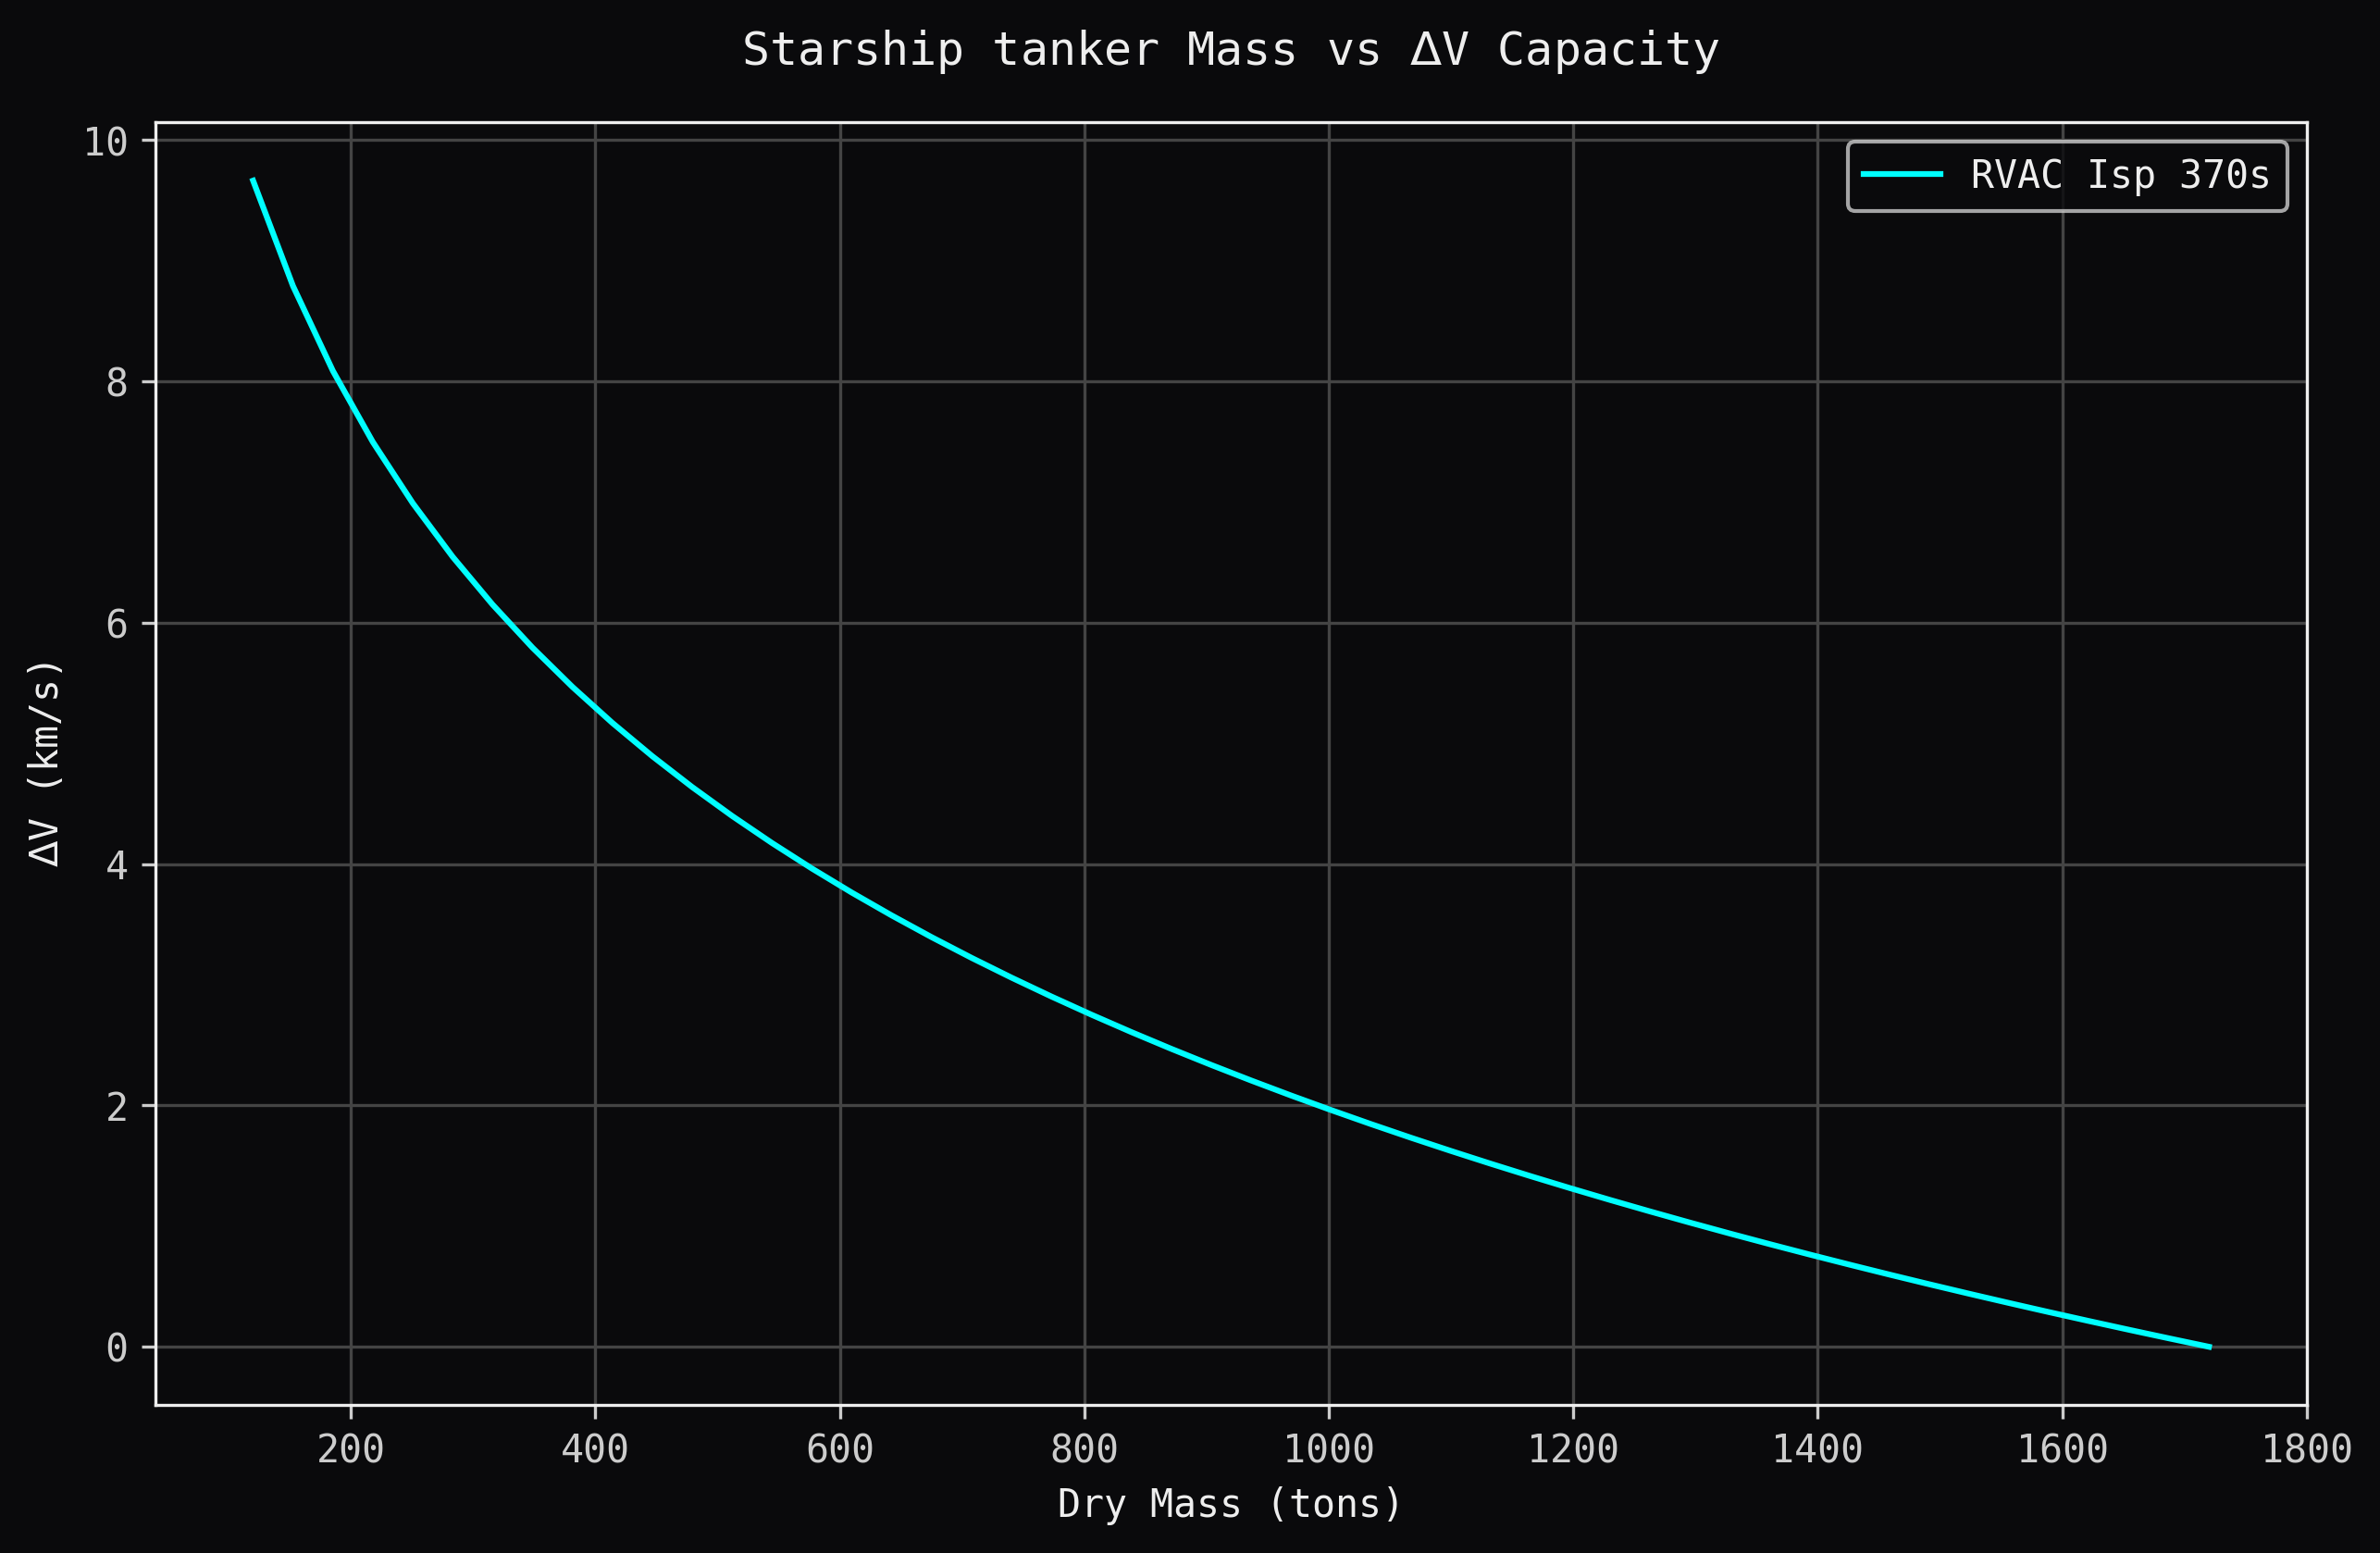

Tanker has 751.02T left at 2.50km/s, burning 848.98T


In [14]:
prop_load=1600
dry_mass=120

mass = np.linspace(dry_mass,prop_load+dry_mass,50)
dv_f = 9.81*370*np.log((dry_mass+prop_load)/mass)*1e-3
fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background') # Start with a dark base

# ----------  Retro‑Sci‑Fi Matplotlib Theme  ----------
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

ax.plot(mass, dv_f, label='RVAC Isp 370s', color='cyan')
ax.grid(True)


ax.legend(loc='upper right')

plt.title("Starship tanker Mass vs $\Delta$V Capacity")
plt.xlabel("Dry Mass (tons)")
plt.ylabel("$\Delta$V (km/s)")
plt.show()

target_dv = 2.5  # km/s

idx = np.argmin(np.abs(dv_f - target_dv))
mass_at_2p5 = mass[idx]
print(f"Tanker has {(mass_at_2p5-dry_mass):.2f}T left at {target_dv:.2f}km/s, burning {(prop_load-(mass_at_2p5-dry_mass)):.2f}T")

In [15]:
370*9.81*np.log(220/120)

2200.0911262191744

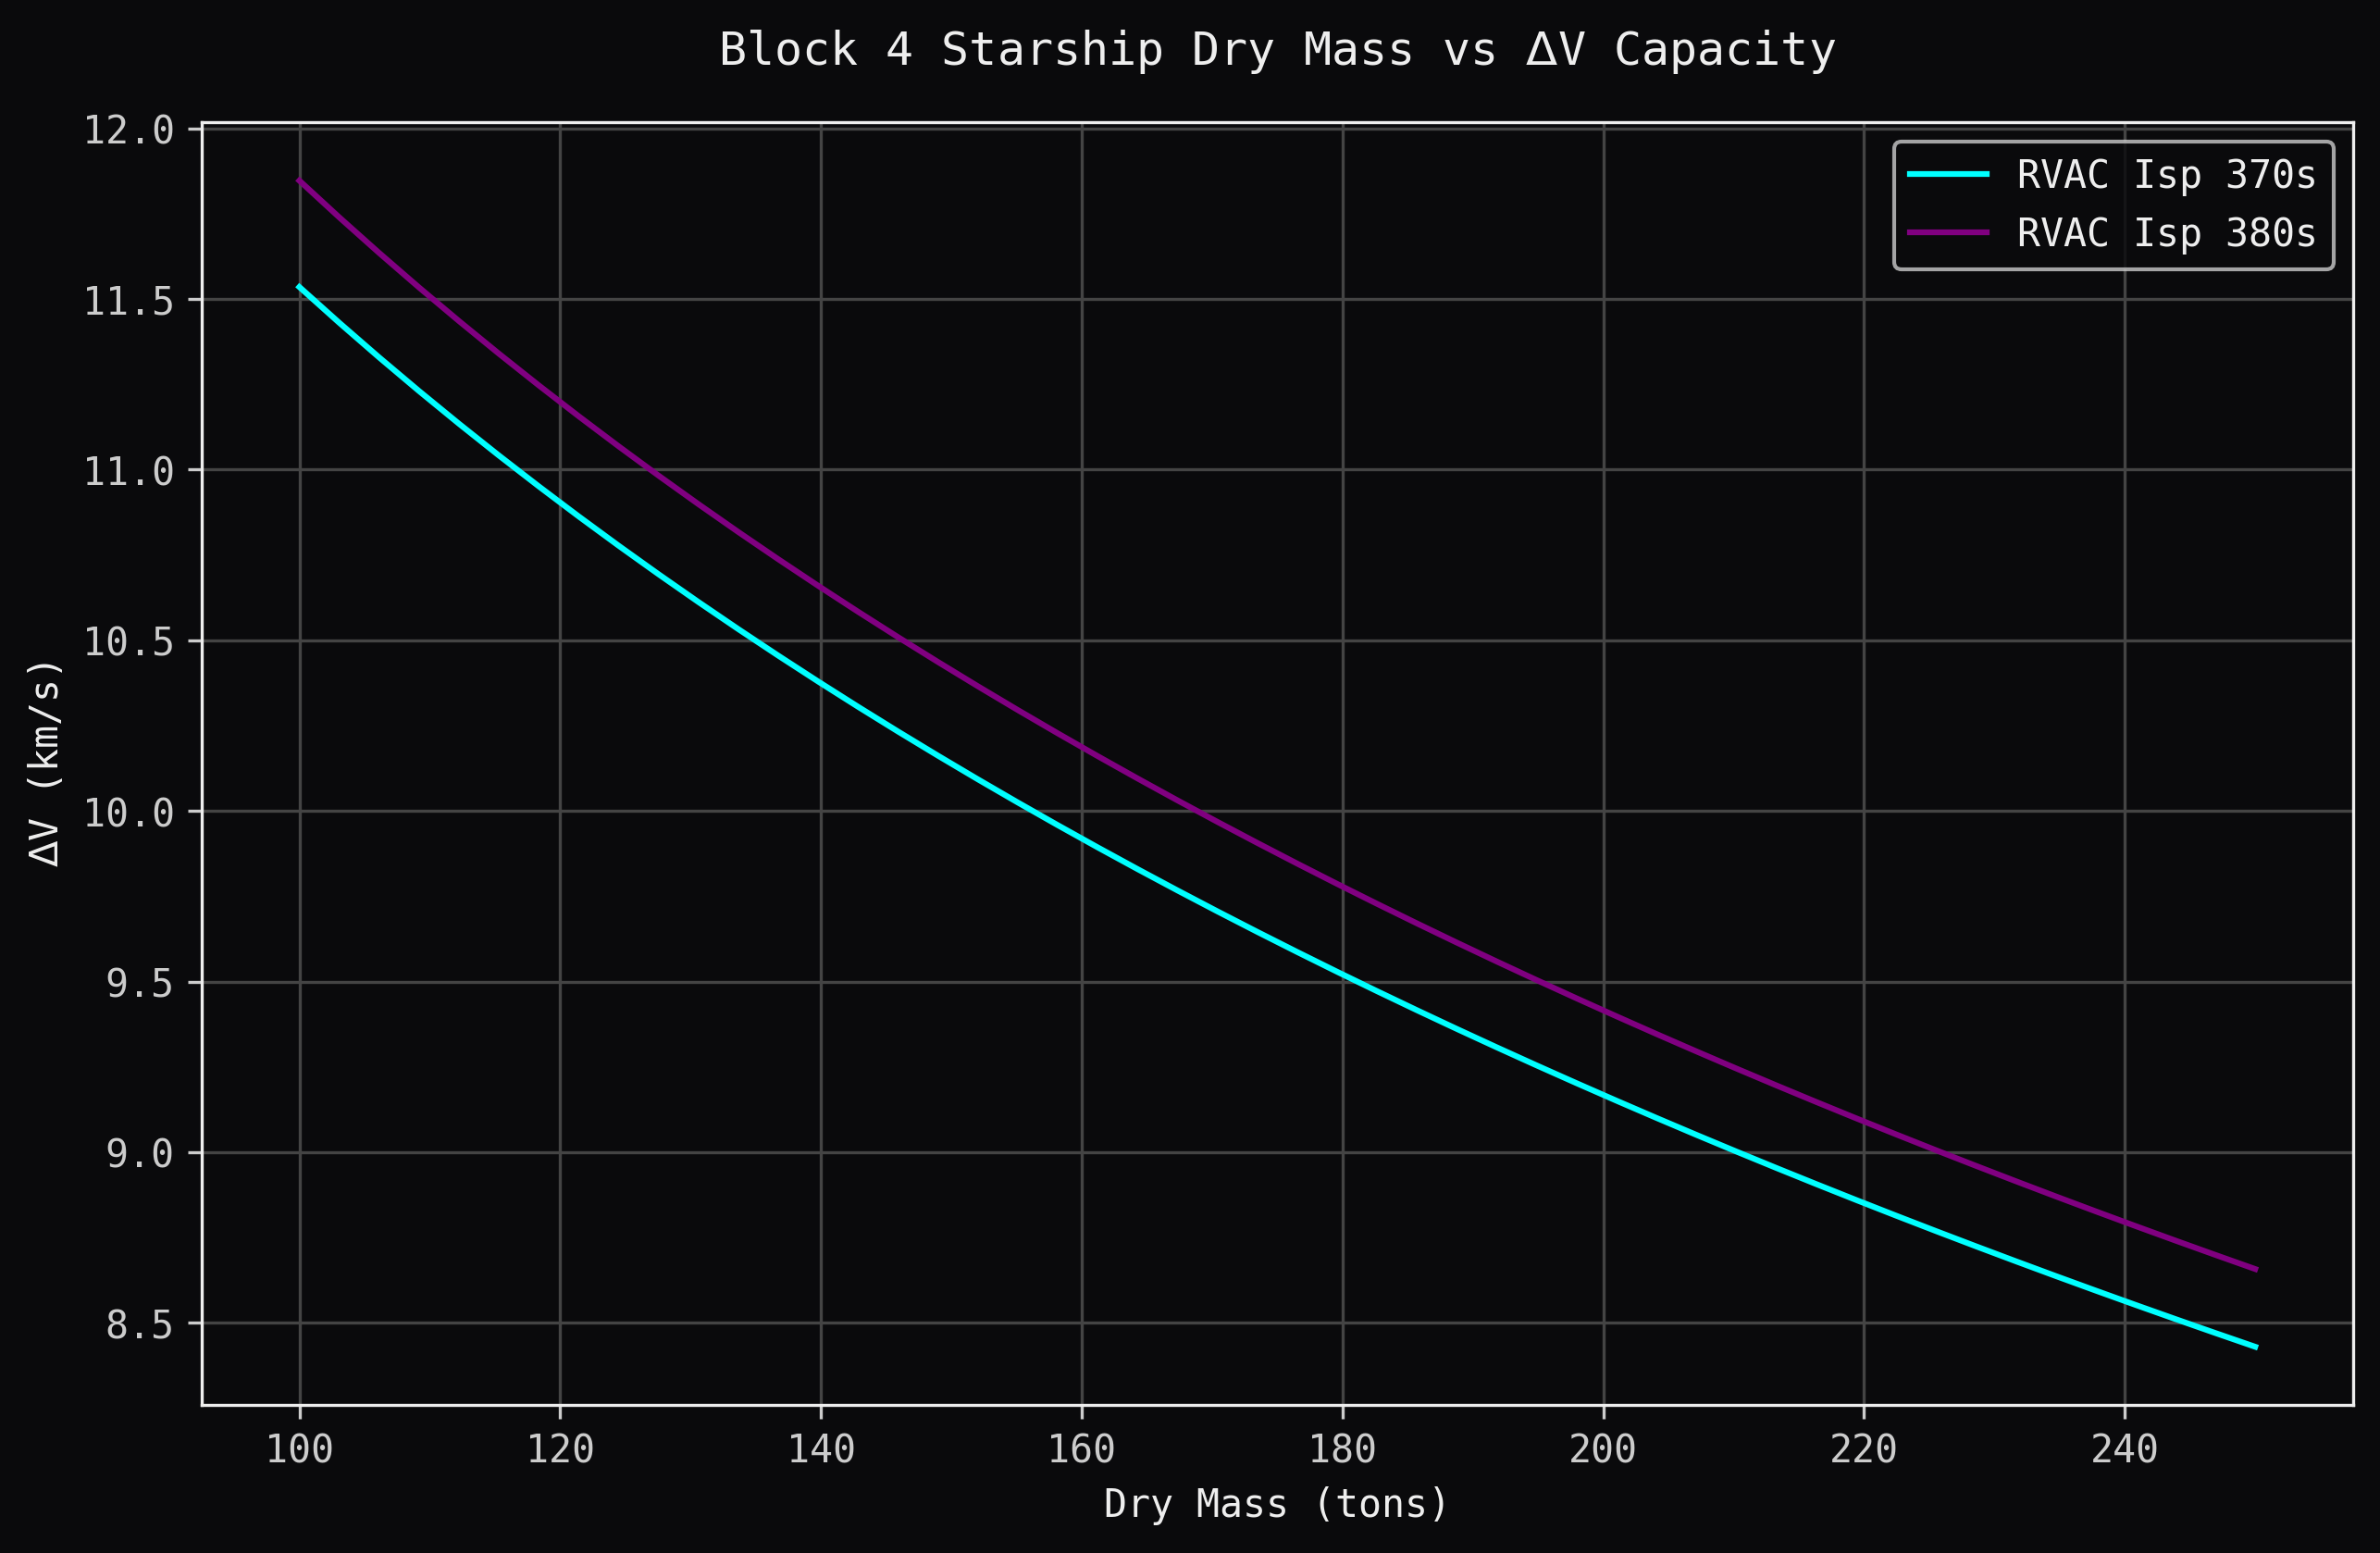

Dry mass of 155.10T gets you 10km/s of DV


In [16]:
prop_load = 2300
dry_mass = np.linspace(100,250,50)
dv_1 = 9.81*370*np.log((prop_load+dry_mass)/dry_mass)*1e-3
dv_2 = 9.81*380*np.log((prop_load+dry_mass)/dry_mass)*1e-3

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background') # Start with a dark base

# ----------  Retro‑Sci‑Fi Matplotlib Theme  ----------
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

ax.plot(dry_mass, dv_1, label='RVAC Isp 370s', color='cyan')
ax.plot(dry_mass, dv_2, label='RVAC Isp 380s', color='purple')
ax.grid(True)


ax.legend(loc='upper right')

plt.title("Block 4 Starship Dry Mass vs $\Delta$V Capacity")
plt.xlabel("Dry Mass (tons)")
plt.ylabel("$\Delta$V (km/s)")
plt.show()

target_dv=10
idx=np.argmin(np.abs(dv_1-target_dv))
print(f"Dry mass of {dry_mass[idx]:.2f}T gets you {target_dv}km/s of DV")


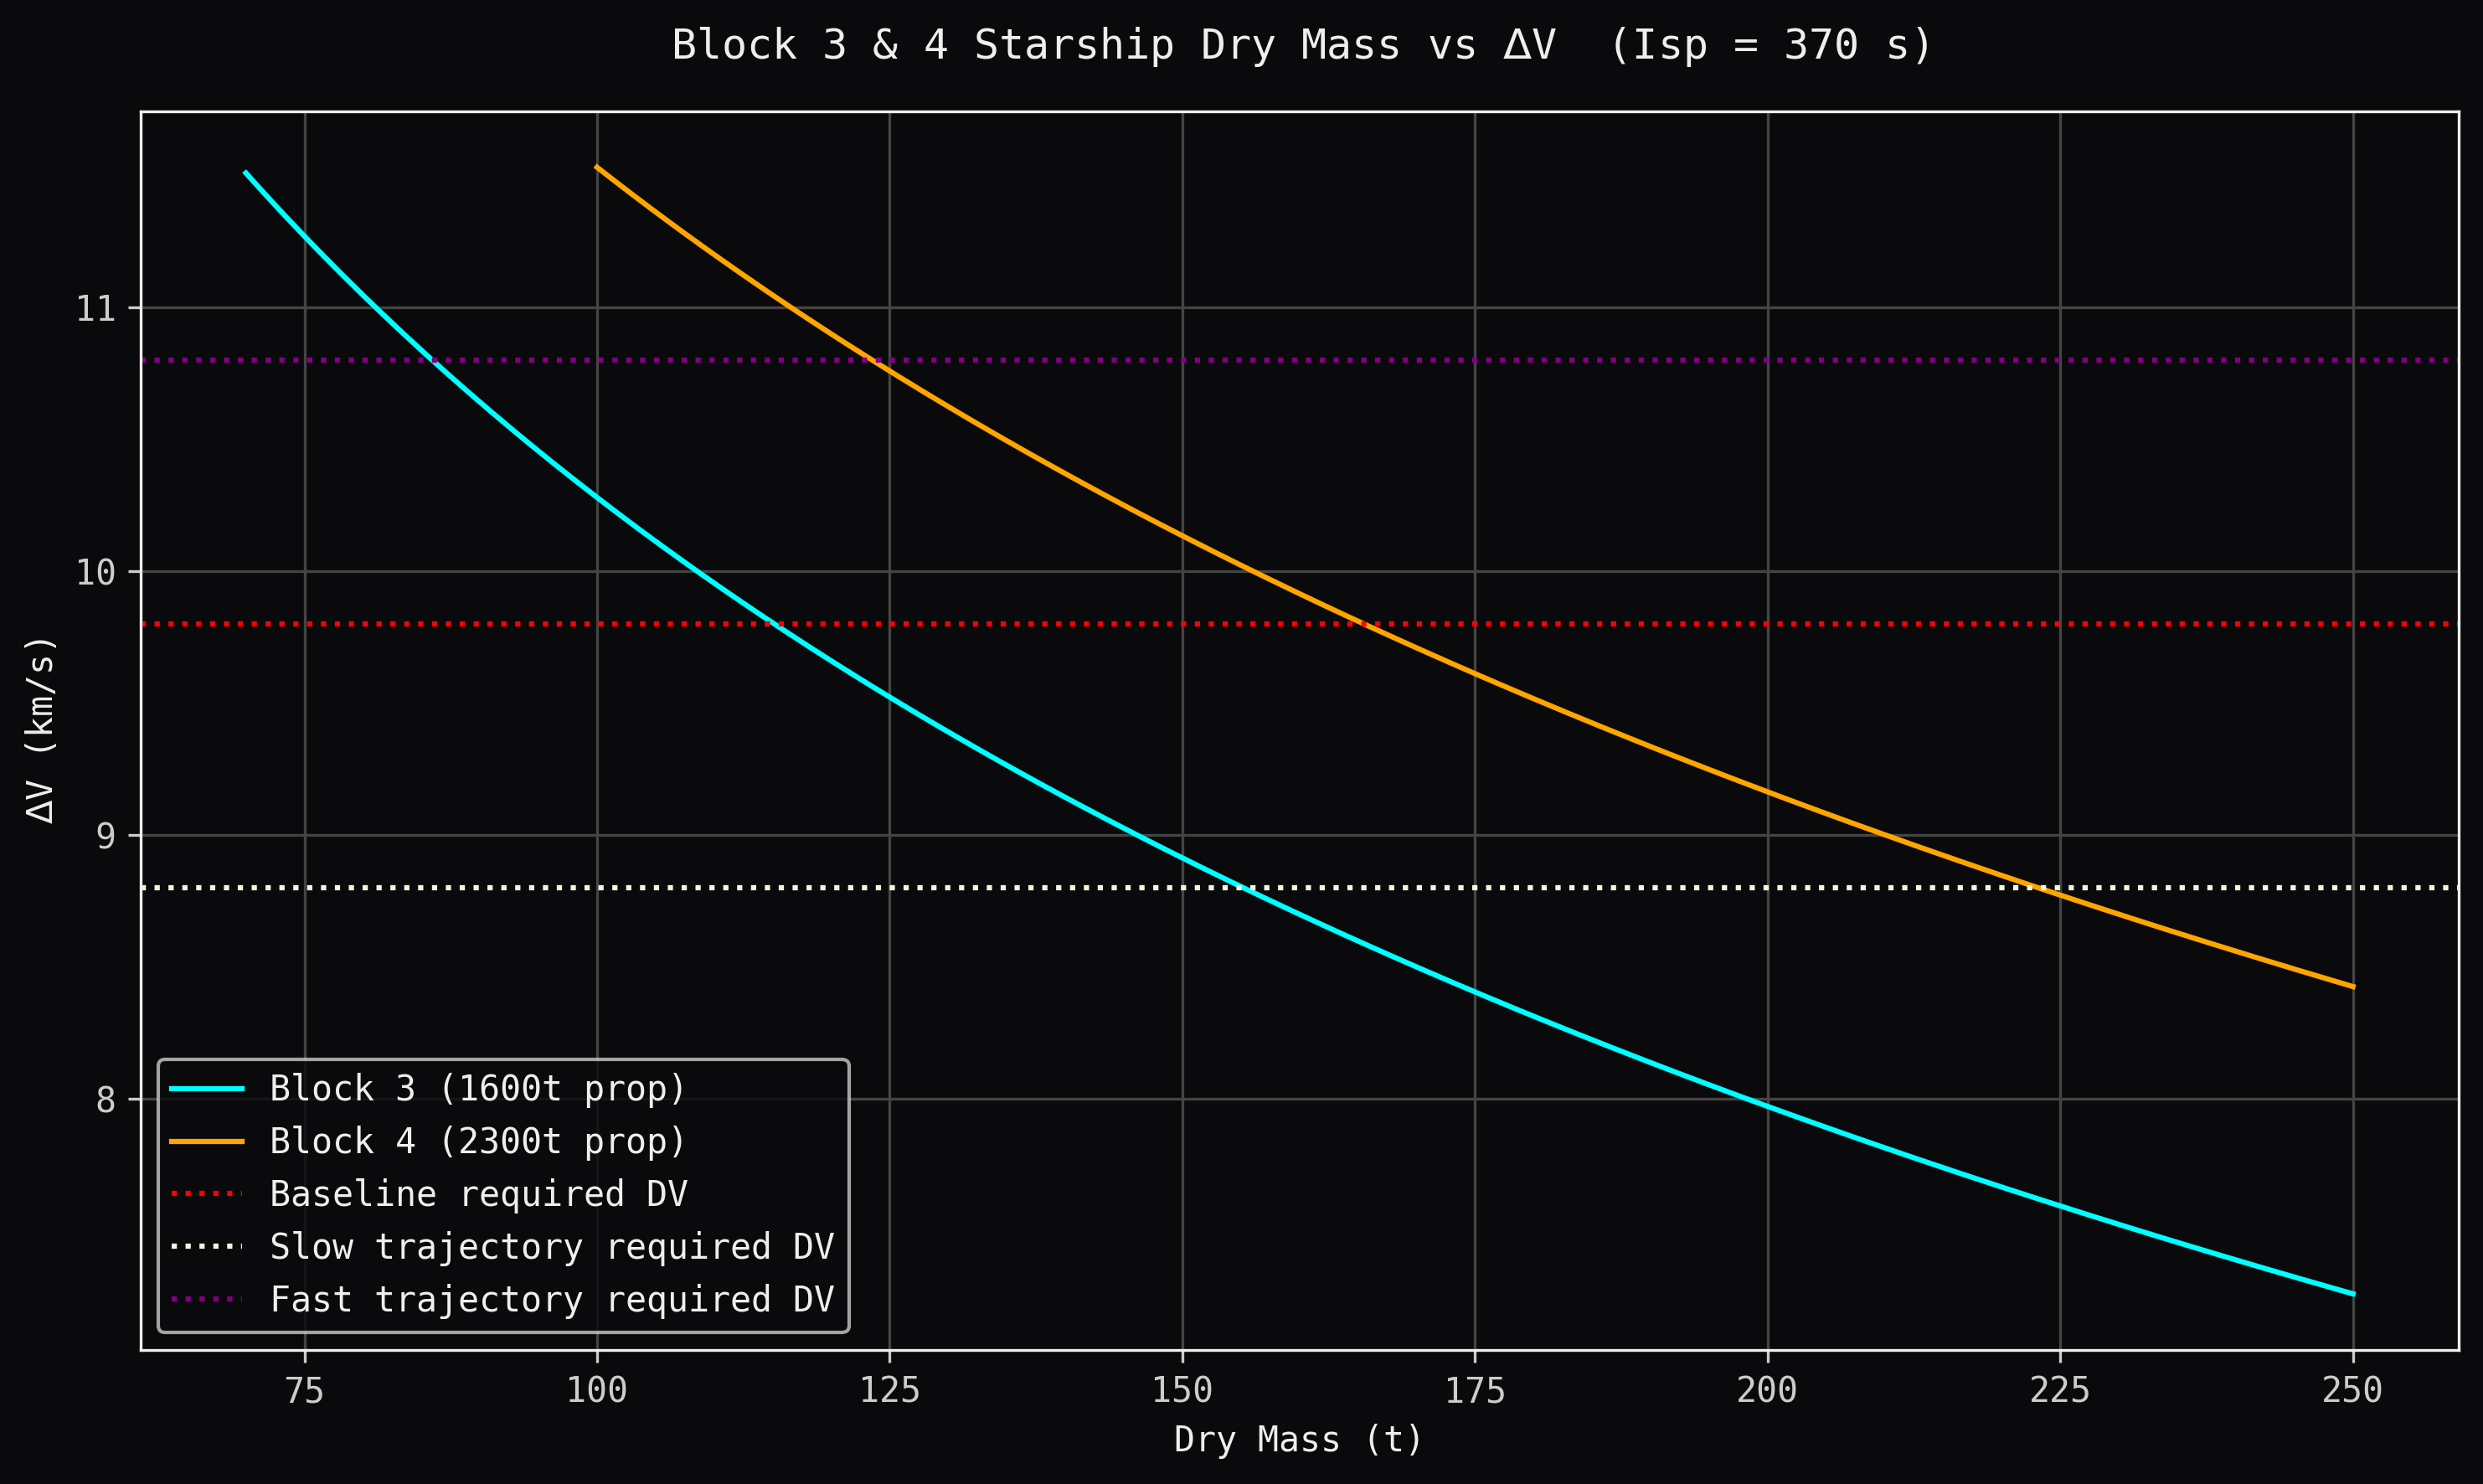

In [17]:
#B3 + B4 dm
isp = 370  # s

# Block 3: 1600t propellant, 70–150t dry mass
dm_b3 = np.linspace(70, 250, 200)
dv_b3 = 9.806 * isp * np.log((1600 + dm_b3) / dm_b3) * 1e-3

# Block 4: 2300t propellant, 100–250t dry mass
dm_b4 = np.linspace(100, 250, 200)
dv_b4 = 9.806 * isp * np.log((2300 + dm_b4) / dm_b4) * 1e-3

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

ax.plot(dm_b3, dv_b3, color='cyan',   label='Block 3 (1600t prop)')
ax.plot(dm_b4, dv_b4, color='orange', label='Block 4 (2300t prop)')
ax.grid(True)
ax.legend(loc='upper right')
plt.axhline(y=9.8, color='red', linestyle='dotted', label='Baseline required DV')
plt.axhline(y=8.8, color='beige', linestyle='dotted', label='Slow trajectory required DV')
plt.axhline(y=10.8, color='purple', linestyle='dotted', label='Fast trajectory required DV')


plt.title("Block 3 & 4 Starship Dry Mass vs $\\Delta$V  (Isp = 370 s)")
plt.xlabel("Dry Mass (t)")
plt.ylabel("$\\Delta$V (km/s)")
plt.tight_layout()
plt.legend()
plt.show()

Text(0.5, 1.0, 'Block 3 Starship: Refuels vs Delta-V Saved naive refuel strategy')

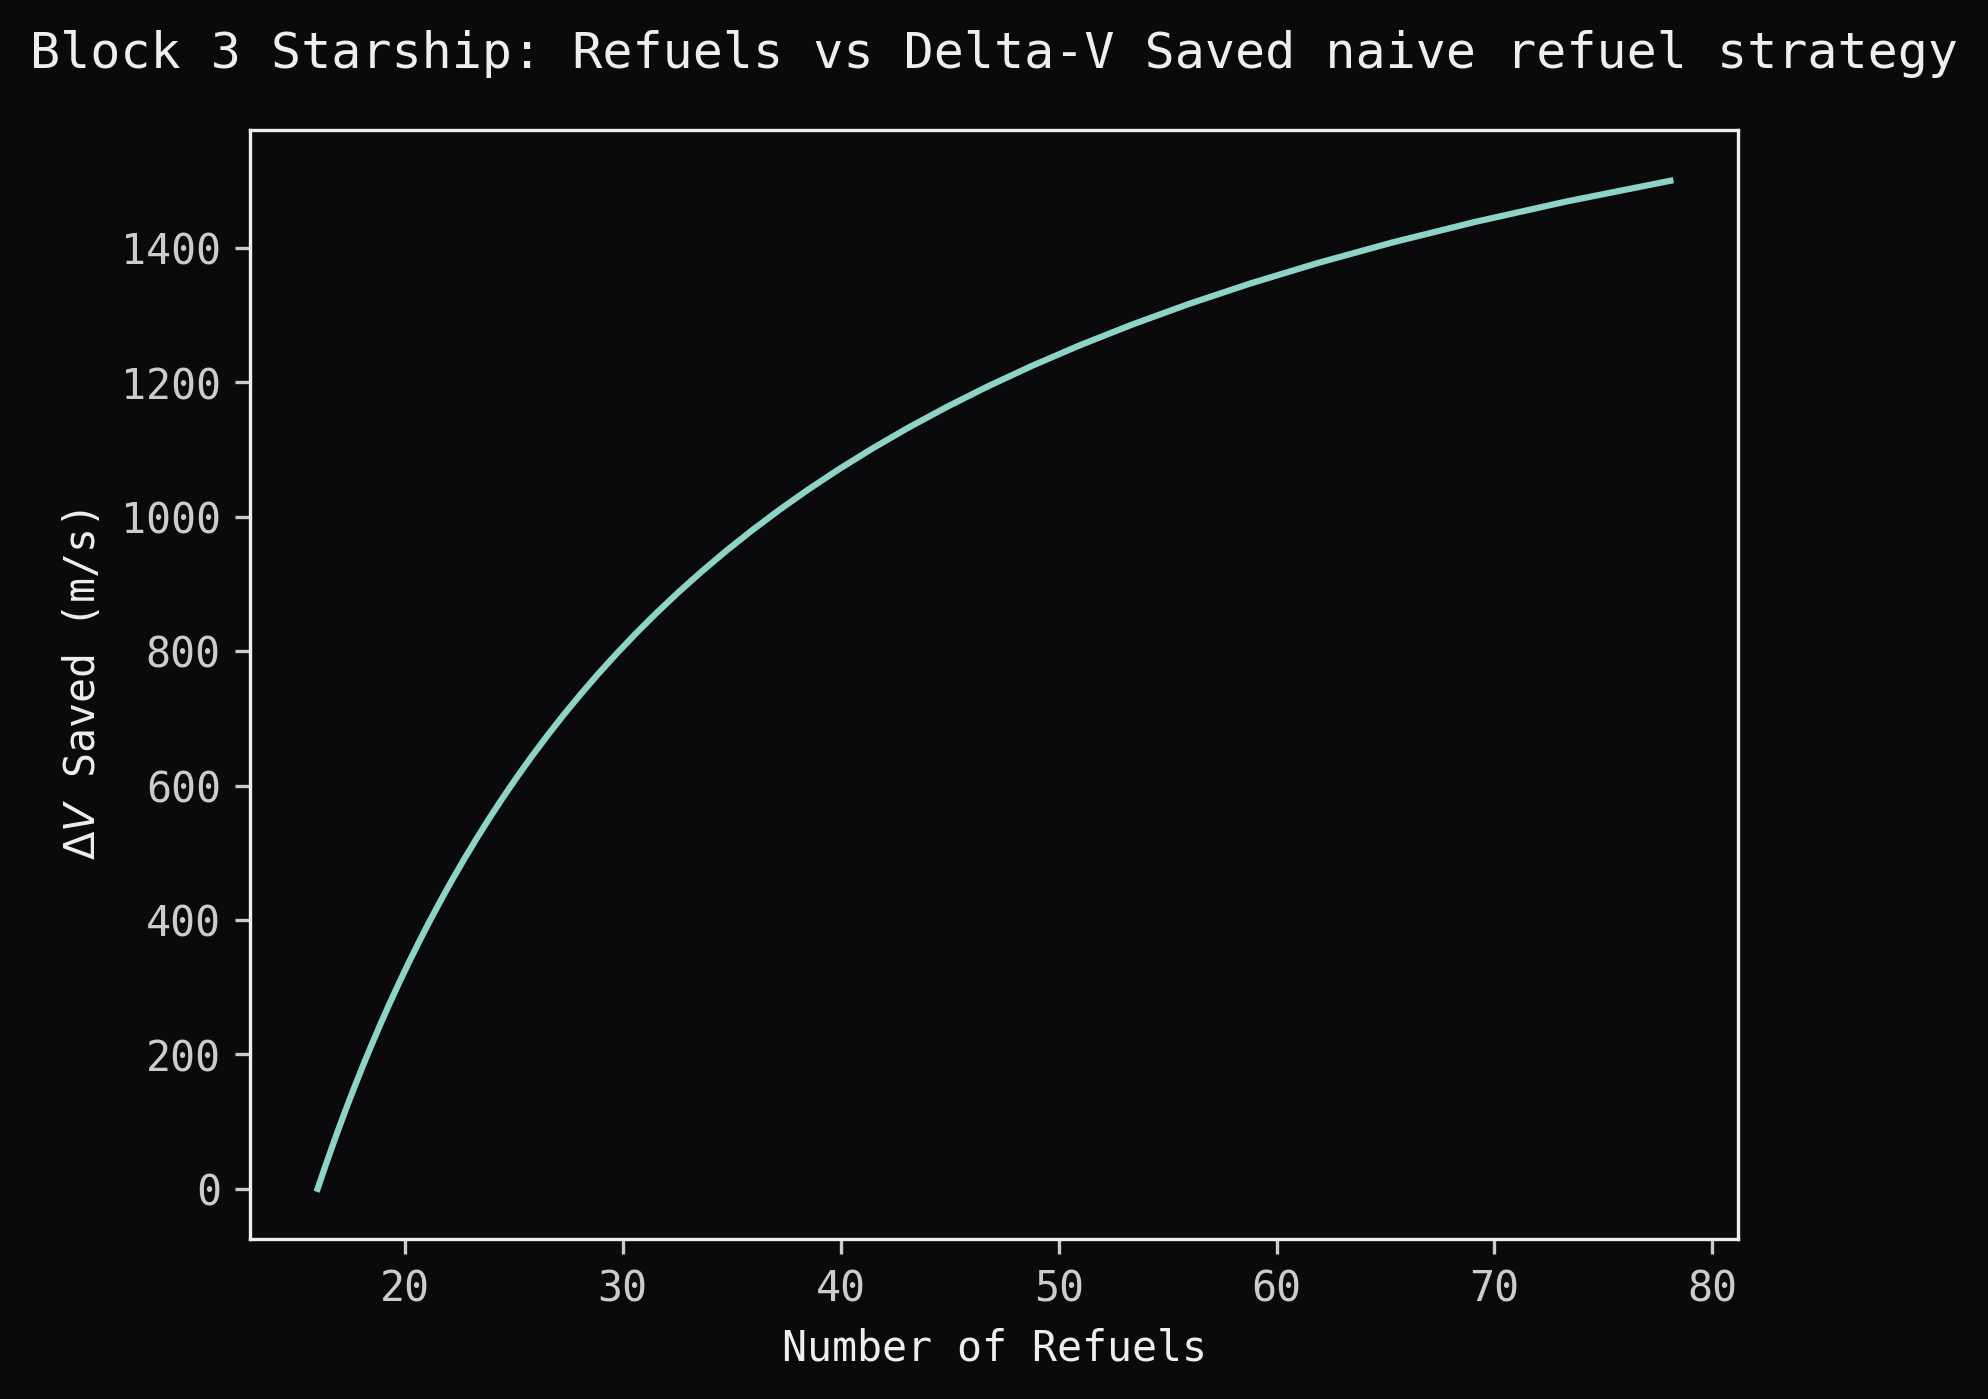

In [18]:
#Starting with a baseline 200km parking orbit, plot graph of saved DV versus number of refuels,
#So, with a block3 starship, dry mass ~140 tons, isp ~380s, propellant load ~1600 tons, LEO payload 100T
#assuming each tanker goes to HEO without refuels


prop_mass = 1600
tanker_prop = 100
dry_mass = 140
isp=380
DV_saved = np.linspace(0,1500,50)
# p=DV_saved/(10*isp)
Tanker_Final_Mass = (dry_mass+tanker_prop)*np.exp(-DV_saved/(9.81*isp))
No_Refuels = prop_mass/(Tanker_Final_Mass - dry_mass)

plt.plot(No_Refuels,DV_saved)
plt.xlabel("Number of Refuels")
plt.ylabel("$\Delta V$ Saved (m/s)")
plt.title("Block 3 Starship: Refuels vs Delta-V Saved naive refuel strategy")


$$\Delta V = g*isp*log(\frac{m_w}{m_d})$$

$$m_w=m_dexp(\frac{\Delta V}{g*isp})$$

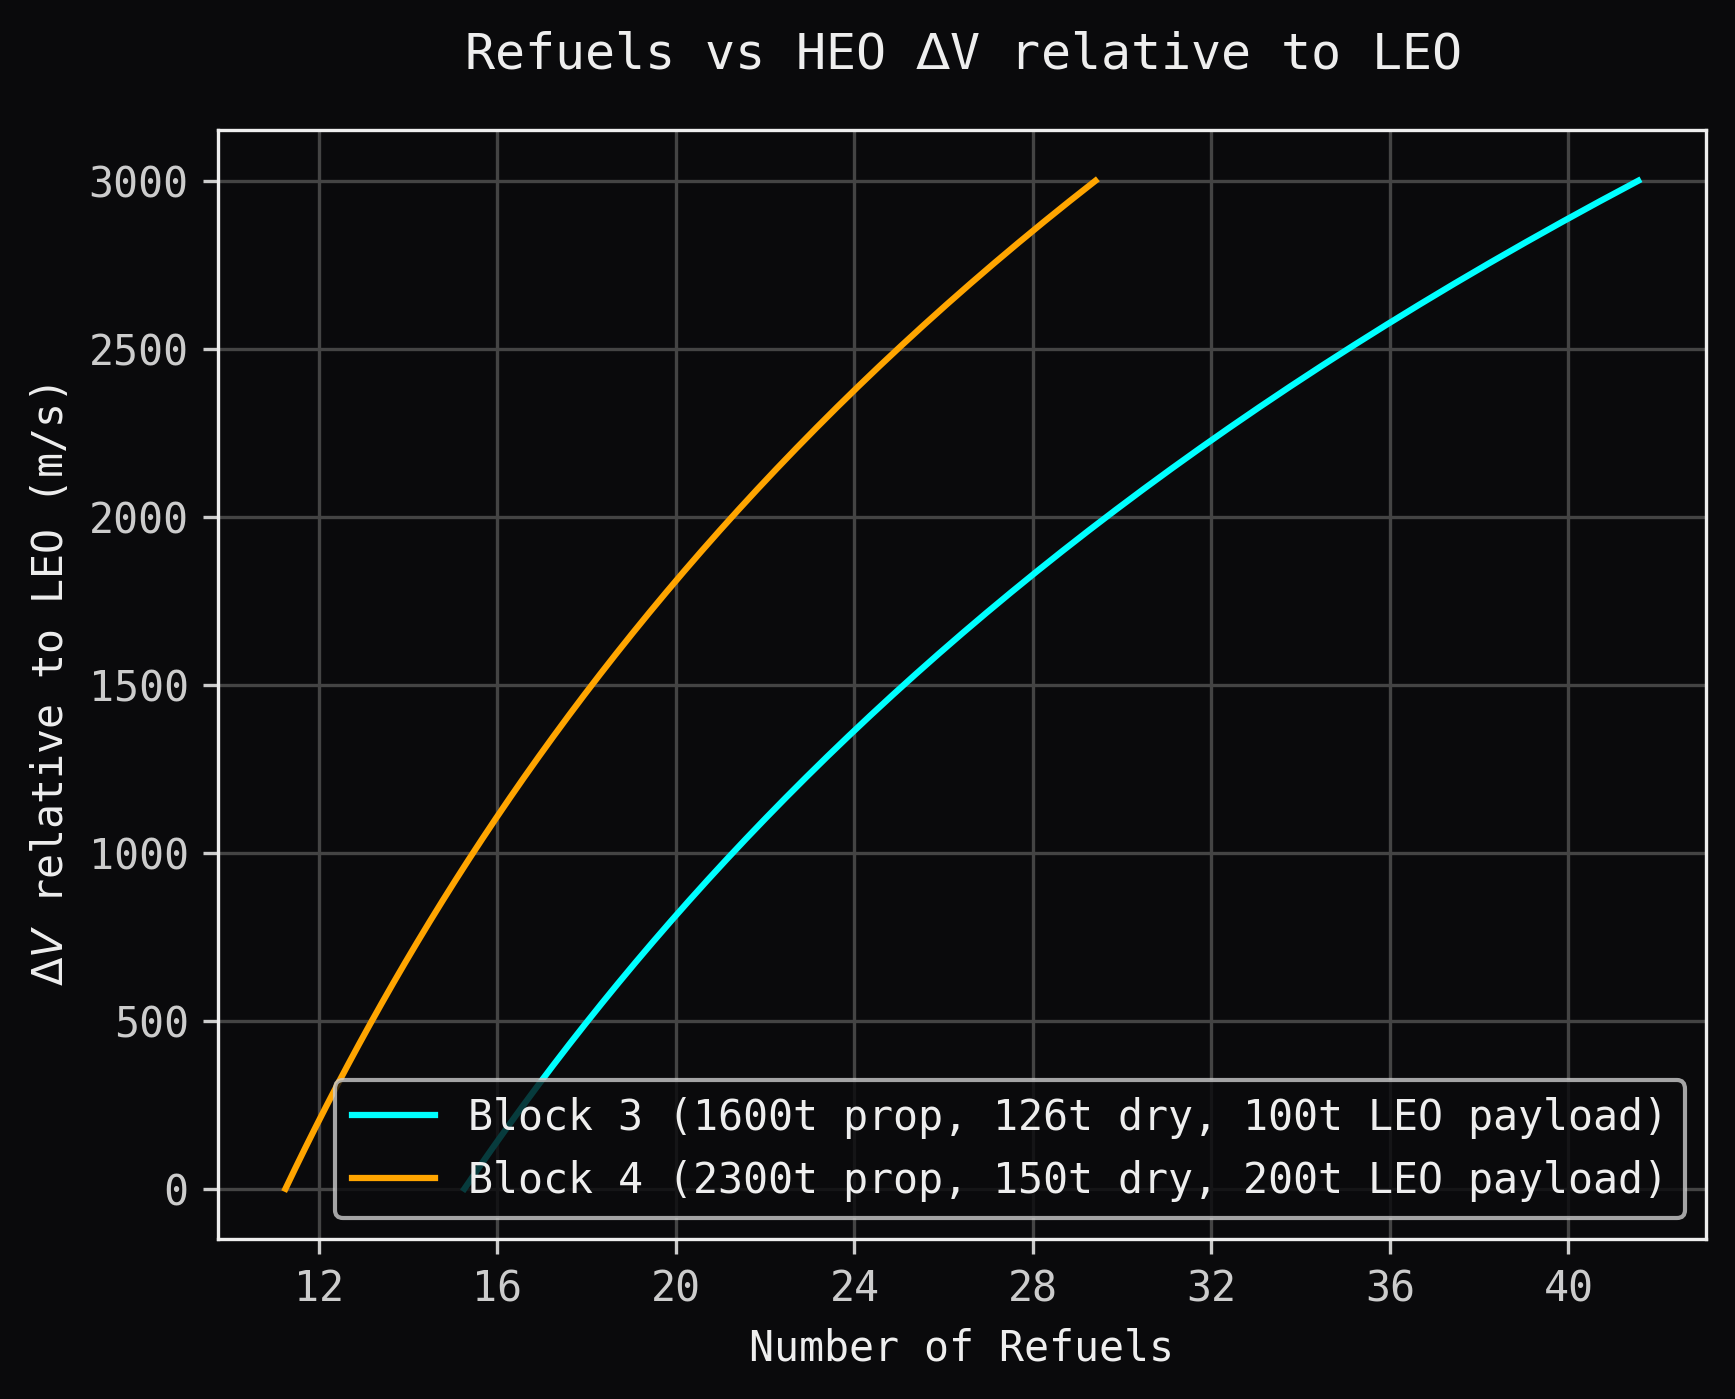

In [22]:
from matplotlib.ticker import MaxNLocator


isp = 370
DV_saved = np.linspace(0, 3000, 50)


def refuels_vs_dv(prop_mass, dry_mass, tanker_prop, isp, DV_saved):
    refuels_per_ship = prop_mass / tanker_prop
    # refuels needed to lift the (initially empty) ship from LEO before it departs
    initial_LEO_mass = dry_mass * np.exp(DV_saved / (9.81 * isp))
    extra_refuels = (initial_LEO_mass - 200) / tanker_prop
    # tanker propellant remaining after climbing to HEO
    Tanker_Final_Mass = (dry_mass + prop_mass) * np.exp(-DV_saved / (9.81 * isp))
    No_Tanker_Refuels = refuels_per_ship * prop_mass / (Tanker_Final_Mass - dry_mass)
    return No_Tanker_Refuels + extra_refuels


# Block 3
b3_refuels = refuels_vs_dv(prop_mass=1600, dry_mass=126, tanker_prop=100,
                           isp=isp, DV_saved=DV_saved)

# Block 4
b4_refuels = refuels_vs_dv(prop_mass=2300, dry_mass=150, tanker_prop=200,
                           isp=isp, DV_saved=DV_saved)

fig, ax = plt.subplots()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.plot(b3_refuels, DV_saved, color='cyan',   label='Block 3 (1600t prop, 126t dry, 100t LEO payload)')
ax.plot(b4_refuels, DV_saved, color='orange', label='Block 4 (2300t prop, 150t dry, 200t LEO payload)')

plt.xlabel("Number of Refuels")
plt.ylabel("$\\Delta V$ relative to LEO (m/s)")
plt.title("Refuels vs HEO $\\Delta$V relative to LEO")
plt.grid(True)
plt.legend()
plt.show()


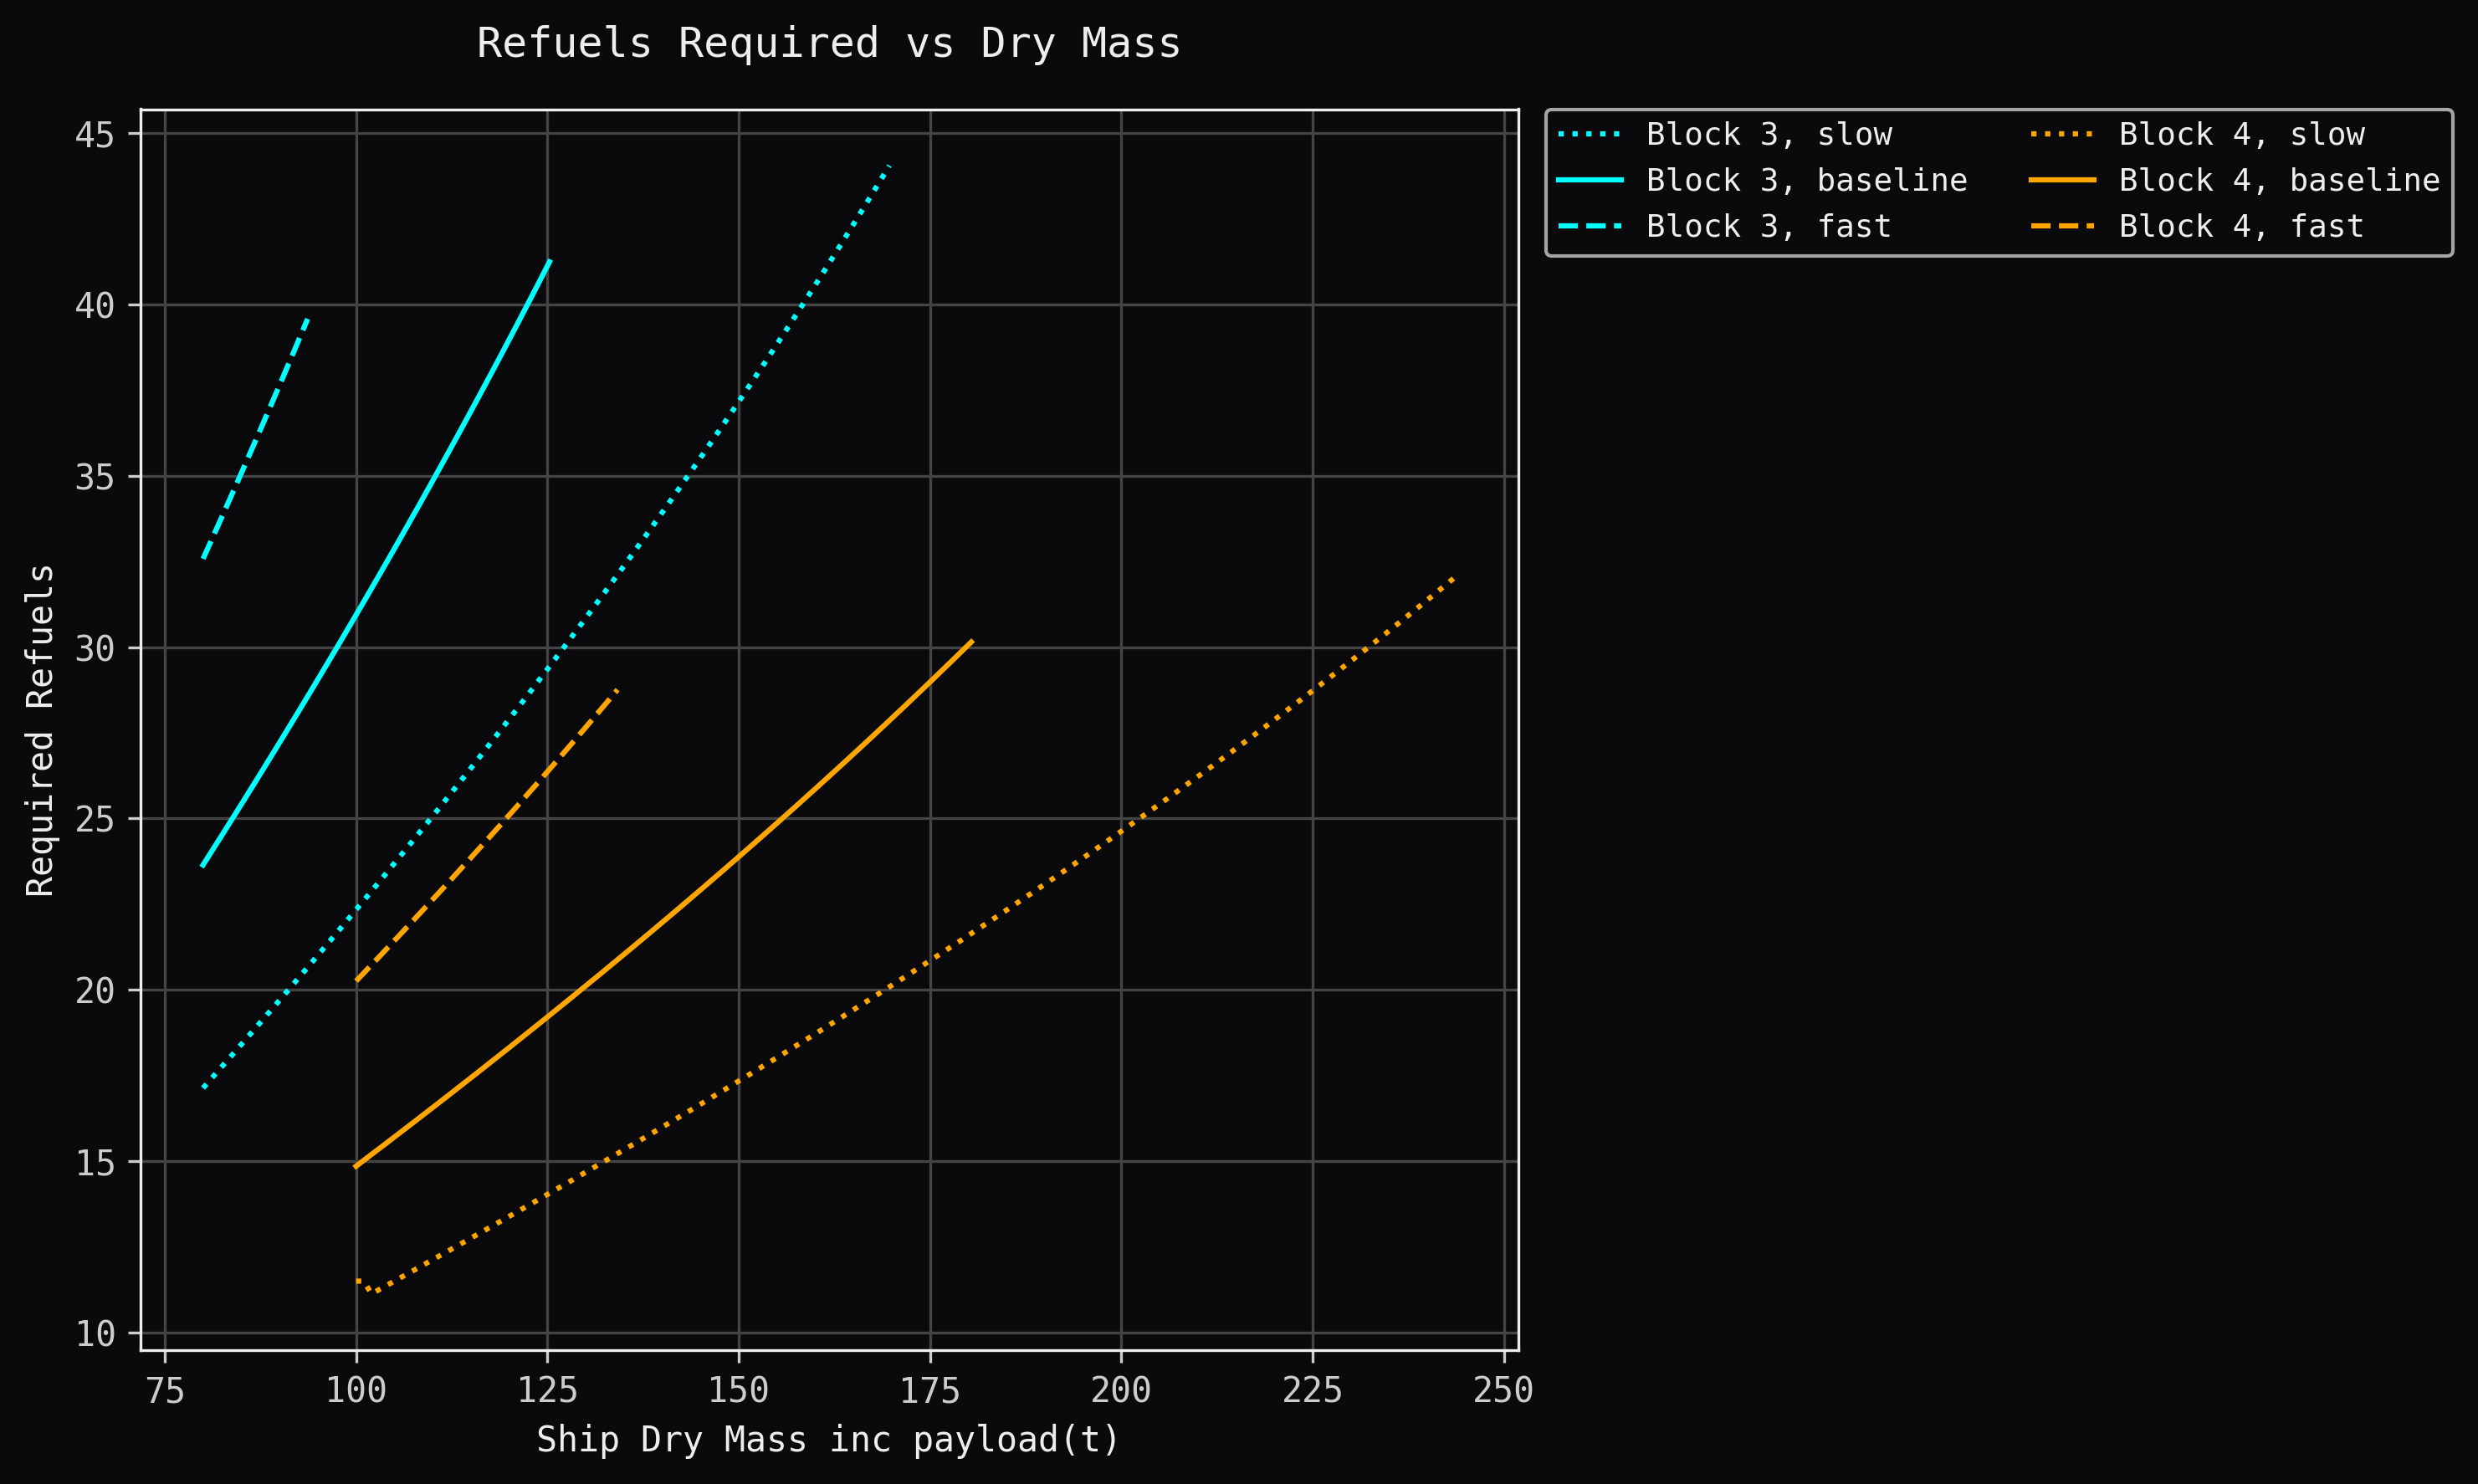

In [20]:
# Refuels vs ship dry mass — iso-ΔV contours for Block 3 & Block 4 at 11.5, 12.5, 13.5 km/s.
# Total ΔV at any (dry_mass, refuels) point is:
#     total_dv = base_dv(dry_mass)              # rocket equation, full prop, LEO start
#               + extra_dv(dry_mass, refuels)   # HEO-refuelling bonus, from refuels_vs_dv()
# HEO bonus capped at 3 km/s (~Earth escape); points needing more are dropped.
# Lower bound: even with zero HEO boost the ship still needs to be fully fuelled
# in LEO, i.e. prop_mass / tanker_prop refuels (= 16 for B3, 11.5 for B4).
isp = 370
g0 = 9.81
trajectories = [
    (11.5, 'slow'),
    (12.5, 'baseline'),
    (13.5, 'fast'),
]
max_heo_boost = 3000              # m/s — cap on usable HEO boost (~Earth escape)

def required_refuels_for_total_dv(dry_mass, prop_mass, tanker_prop, isp, target_dv):
    base_dv = isp * g0 * np.log((dry_mass + prop_mass) / dry_mass)
    needed_extra = target_dv - base_dv
    min_refuels = prop_mass / tanker_prop      # refuels to fully fuel the ship in LEO
    if needed_extra <= 0:
        return min_refuels
    if needed_extra > max_heo_boost:
        return np.nan                          # cannot close ΔV budget within the 3 km/s cap
    return refuels_vs_dv(prop_mass, dry_mass, tanker_prop, isp, needed_extra)

# Dry-mass sweeps — same prop / tanker assumptions as the cell above
dm_b3 = np.linspace(80, 250, 200)
dm_b4 = np.linspace(100, 300, 200)

fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0A0A0C',
    'axes.facecolor':   '#0A0A0C',
    'axes.edgecolor':   '#EEEEEE',
    'axes.labelcolor':  '#EEEEEE',
    'text.color':       '#EEEEEE',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'grid.color':       '#444444',
    'font.family':      'monospace',
    'axes.titlepad':    15,
})

# Line style per trajectory; colour per block
linestyle_for_traj = {'slow': ':', 'baseline': '-', 'fast': '--'}

# Plot ALL Block 3 curves first, then ALL Block 4 curves, so matplotlib's
# column-major legend fill puts Block 3 in the left column and Block 4 in the right.
for dv_kms, traj_name in trajectories:
    target_dv = dv_kms * 1000
    ls = linestyle_for_traj[traj_name]
    b3_refuels = np.array([
        required_refuels_for_total_dv(dm, prop_mass=1600, tanker_prop=100,
                                      isp=isp, target_dv=target_dv)
        for dm in dm_b3
    ])
    ax.plot(dm_b3, b3_refuels, color='cyan', linestyle=ls,
            label=f'Block 3, {traj_name}')

for dv_kms, traj_name in trajectories:
    target_dv = dv_kms * 1000
    ls = linestyle_for_traj[traj_name]
    b4_refuels = np.array([
        required_refuels_for_total_dv(dm, prop_mass=2300, tanker_prop=200,
                                      isp=isp, target_dv=target_dv)
        for dm in dm_b4
    ])
    ax.plot(dm_b4, b4_refuels, color='orange', linestyle=ls,
            label=f'Block 4, {traj_name}')

ax.set_xlabel("Ship Dry Mass inc payload(t)")
ax.set_ylabel("Required Refuels")
ax.set_title(
    f"Refuels Required vs Dry Mass"
)
ax.grid(True)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0),
          ncol=2, fontsize=9, borderaxespad=0.)
plt.tight_layout()
plt.show()


Mass ratio of 14.9 occurs at payload of 3.67T


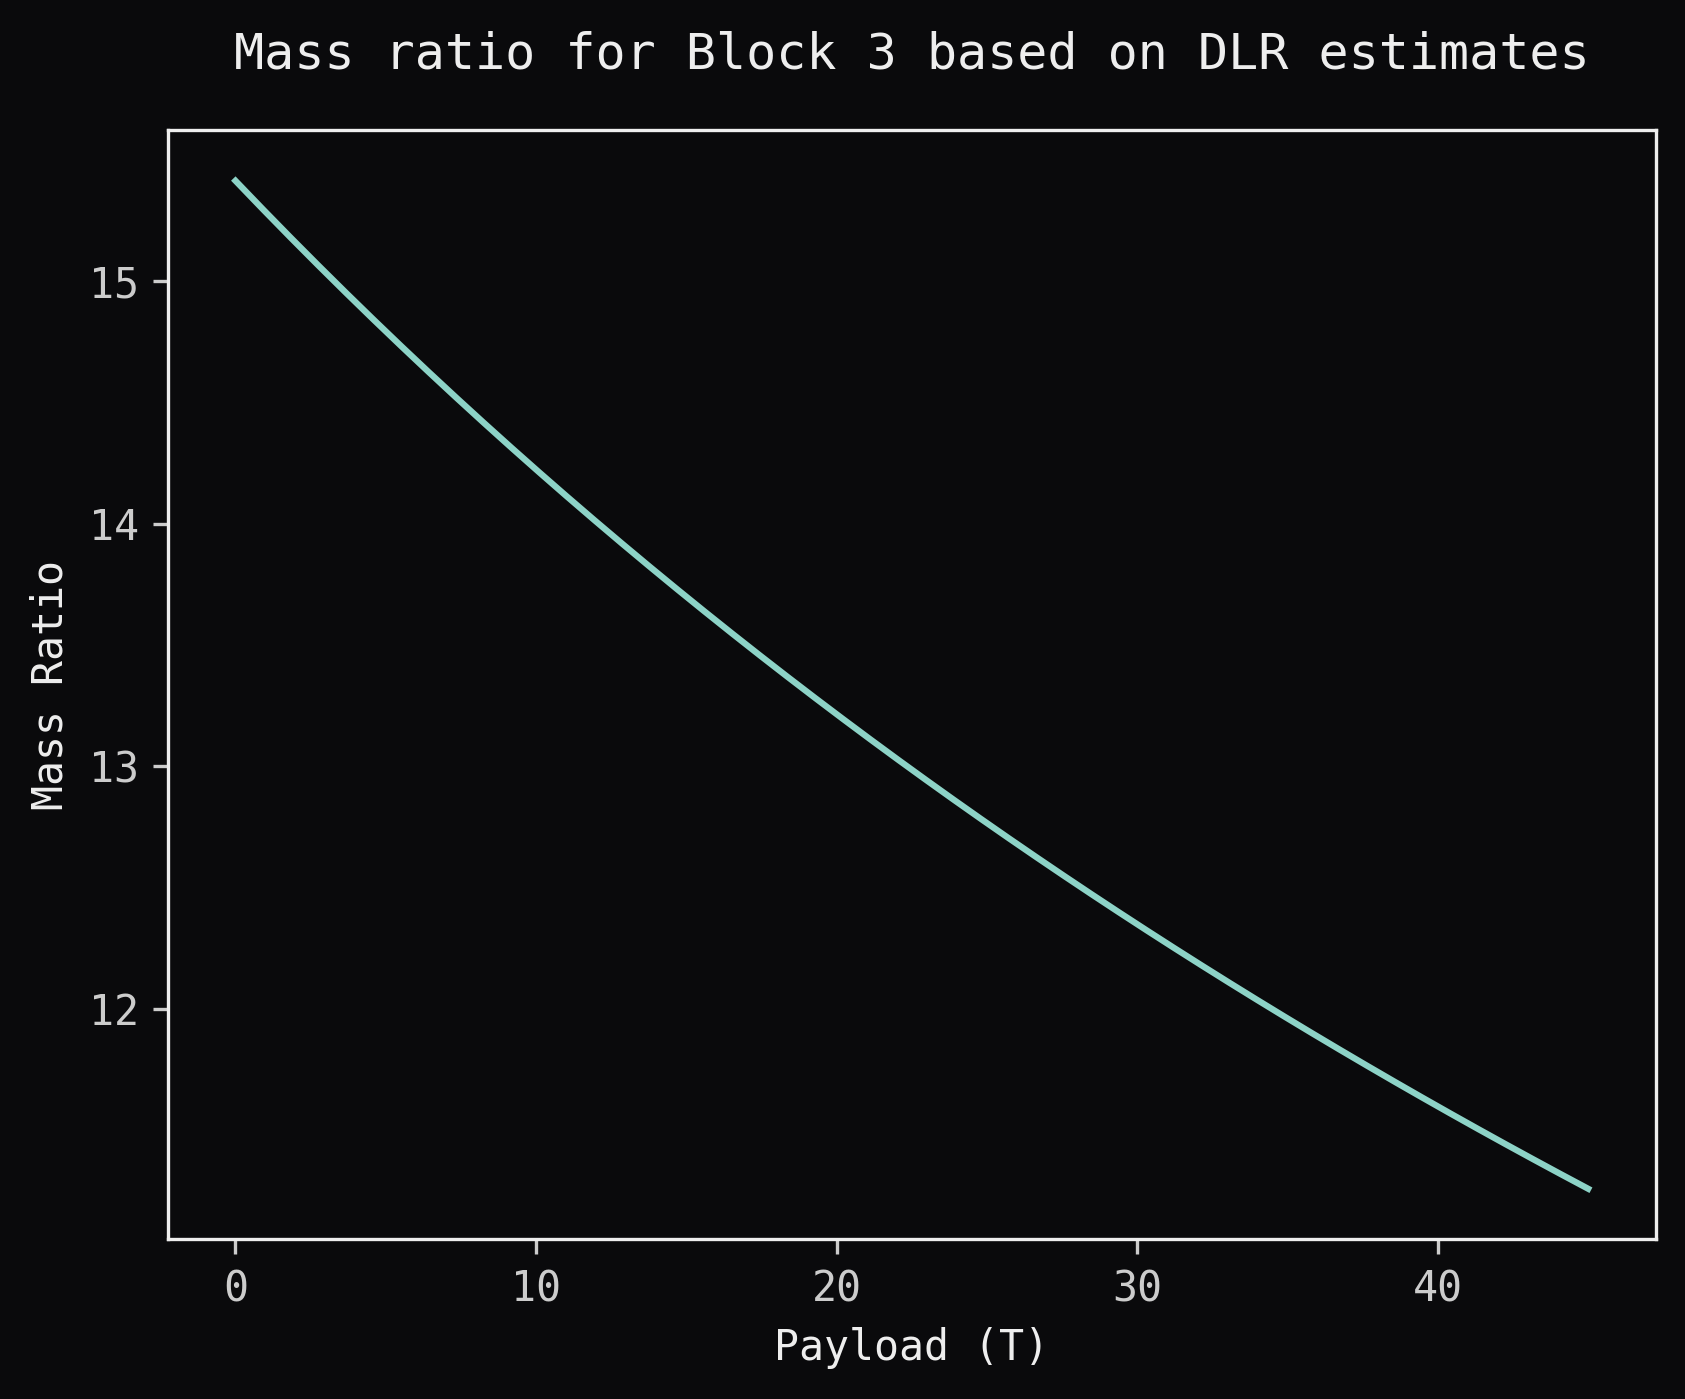

In [28]:
#mass ratio calculator
# dry_mass=np.linspace(100,150,50)
dry_mass = 111
prop_load=1600
isp=370
payload=np.linspace(0,45,50)
mass_ratio=(dry_mass+prop_load+payload)/(dry_mass+payload)
plt.plot(payload,mass_ratio)
plt.xlabel("Payload (T)")
plt.ylabel("Mass Ratio")    
plt.title('Mass ratio for Block 3 based on DLR estimates')

# plt.axhline(y=14.9, color='red', linestyle='dotted', label='Mass ratio for baseline trajectory')
# plt.axhline(y=11.3, color='beige', linestyle='dotted', label='Mass ratio for slow trajectory')
# plt.legend()
target_mass_ratio=14.9
idx=np.argmin(np.abs(mass_ratio-target_mass_ratio))
print(f"Mass ratio of {target_mass_ratio:.1f} occurs at payload of {payload[idx]:.2f}T")

In [21]:
print(803*292)

234476
